## Exemple d'utilisation de TCA (unidimensionnel)

Cette section illustre une utilisation complète du package `trajectoryclusteringanalysis` dans le cas d'un jeu de données unidimensionnel, ici on utilise `unidimisional_data`. 

Ce jeu de données suit l'évolution clinique de patients sur plusieurs mois.
La variable d'intérêt est le **`care_status`**, qui représente l'état du patient à un mois ($t$) donné :
* **`D` : Diagnostiqué**
* **`C` : Consultation**
* **`T` : Traitement**
* **`S` : Infection contrôlée**

Pour chaque patient, nous disposons de ces variables (j'ai choisi cette interprétation)
* `age` (catégoriel) (1.0: Jeune, 2.0: Adulte, 3.0: Senior)
* `sex` (0: Homme, 1: Femme).
* `education` (niveau d'études) (1.0: Basse, 2.0: Moyenne, 3.0: Haute).
* `wealth` (indice de richesse) (1.0: Pauvre, 2.0: Moyen, 3.0: Riche).
* `distance_clinic` (proximité géographique avec le centre de soins) (1.0: Proche, 2.0: Éloigné).


> **Objectif** : Regrouper les patients ayant des parcours de soins similaires et ajouter des fonctions qui permettent d'interpréter si des facteurs comme la précarité (`wealth`) ou l'éloignement (`distance_clinic`) influencent la probabilité d'atteindre rapidement l'état d'infection contrôlée' (`S`).

1. Import des fonctions et librairies utilisées ainsi que du jeu de données
2. Préparation du jeu de données et initialisation du TCA
3. Calcul des `distance_matrix` pour différentes distances (Hamming, Levenshtein, Optimal-Matching, ...)
4. Clustering avec différentes méthodes (CAH, K-means, K-medoids)
5. Ajouts

> **Note** : On ne code pas NaN comme un état dans ce cas, on a seulement plus de données mais on ne base pas les analyses dessus

# 1. Imports

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA
from trajectoryclusteringanalysis.ajouts import *

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


Fonctions

In [2]:
df = pd.read_csv(project_root / "data" / "unidimensional_data.csv")
df.head()

,id,month,care_status,sex,age,education,wealth,distance_clinic
0,3,0.0,D,1.0,1.0,2.0,2.0,1.0
1,3,1.0,D,1.0,1.0,2.0,2.0,1.0
2,3,2.0,D,1.0,1.0,2.0,2.0,1.0
3,3,3.0,D,1.0,1.0,2.0,2.0,1.0
4,3,4.0,D,1.0,1.0,2.0,2.0,1.0


# 2. Préparation du jeu de données et initialisation du TCA

On transforme les données pour obtenir une matrice individus-mois. Ce format ne conserve que l'évolution temporelle en supprimant les autres variables afin de simplifier l'analyse.

In [3]:
colonnes_stats = ['sex', 'age', 'education', 'wealth', 'distance_clinic']

wide_df, col_stats = long_to_wide_format(df, id_col="id", time_col="month", value_col="care_status", prefix="month_", static_cols = colonnes_stats, shift_time=True, sample_frac=0.1, random_state=42)

label_var = {
    'sex': {0.0: 'Homme', 1.0: 'Femme'},
    'distance_clinic': {1.0: 'Proche', 2.0: 'Éloigné'},
    'wealth': {1.0: 'Pauvre', 2.0: 'Moyen', 3.0: 'Riche'},
    'education': {1.0: 'Basse', 2.0: 'Moyenne', 3.0: 'Haute'},
    'age': {1.0: 'Jeune', 2.0: 'Adulte', 3.0: 'Senior'}
}

wide_df.head()

,id,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,...,month_40,month_41,month_42,month_43,month_44,month_45,month_46,month_47,month_48,month_49
0,84,D,C,C,C,C,D,D,D,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,196,D,D,D,D,D,D,D,D,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,213,D,C,C,C,C,C,C,C,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,222,D,D,D,D,C,T,T,S,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,282,D,C,C,C,C,C,C,C,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


On peut maintenant créer une instance de TCA pour l'analyse unidimensionelle :

In [4]:
tca = TCA(data=wide_df,
              index_col='id',
              time_col=None,  # Pas utilisé dans l'analyse unidimensionnelle
              event_col=None,  # Pas utilisé dans l'analyse unidimensionnelle
              alphabet=['D', 'C', 'T', 'S'],
              states=["diagnostiqué", "en soins", "sous traitement", "inf. contrôlée"], 
              mode='unidimensional',
              )

INFO:root:TCA object initialized successfully
INFO:root:The unidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (292, 50)
state coding:
   alphabet            label  label encoded
0        D     diagnostiqué              1
1        C         en soins              2
2        T  sous traitement              3
3        S   inf. contrôlée              4


# 3. Calcul des distances

On calcule d'abord nos matrice de coûts (erreur pour la matrice pour les fréquences)

In [5]:
# Méthode 1 : Matrice de coût constante
cost_matrix_constant = tca.compute_substitution_cost_matrix()
cost_matrix_constant

,D,C,T,S
D,0.0,2.0,2.0,2.0
C,2.0,0.0,2.0,2.0
T,2.0,2.0,0.0,2.0
S,2.0,2.0,2.0,0.0


In [6]:
#Méthode 2 : Matrice de coût basée sur les fréquences d'observation
cost_matrix_frequency = tca.compute_substitution_cost_matrix(method='frequency')
cost_matrix_frequency

,D,C,T,S
D,0.000000,1.877628,1.974524,1.988967
C,1.877628,0.000000,1.853099,1.948162
T,1.974524,1.853099,0.000000,1.841050
S,1.988967,1.948162,1.841050,0.000000


In [7]:
# Méthode 3 : Matrice de coût customisée
couts = {
    'D:D': 0.0, 'D:C': 1.5, 'D:T': 2.0, 'D:S': 3.0,
    'C:D': 1.5, 'C:C': 0.0, 'C:T': 1.0, 'C:S': 2.5,
    'T:D': 2.0, 'T:C': 1.0, 'T:T': 0.0, 'T:S': 1.0,
    'S:D': 3.0, 'S:C': 2.5, 'S:T': 1.0, 'S:S': 0.0
}
cost_matrix_custom = tca.compute_substitution_cost_matrix(method='custom', custom_costs=couts)
cost_matrix_custom

,D,C,T,S
D,0.0,1.5,2.0,3.0
C,1.5,0.0,1.0,2.5
T,2.0,1.0,0.0,1.0
S,3.0,2.5,1.0,0.0


On peut visualiser ces matrices de coûts sous forme de carte de chaleur, plus on s'approche du rouge, plus le coût est élevé, plus on s'approche du jaune, plus le coût est faible.

Affichage des Heatmaps :


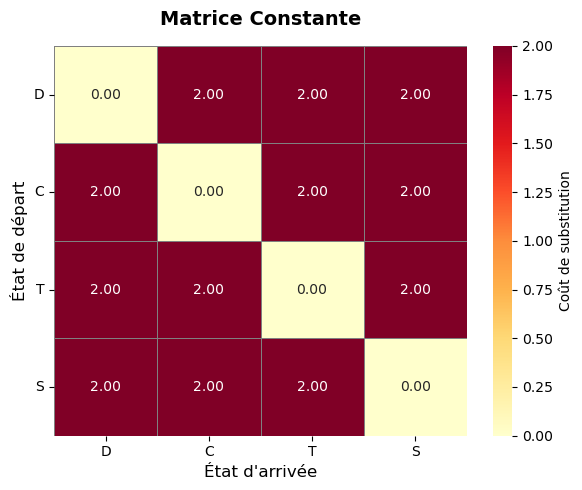

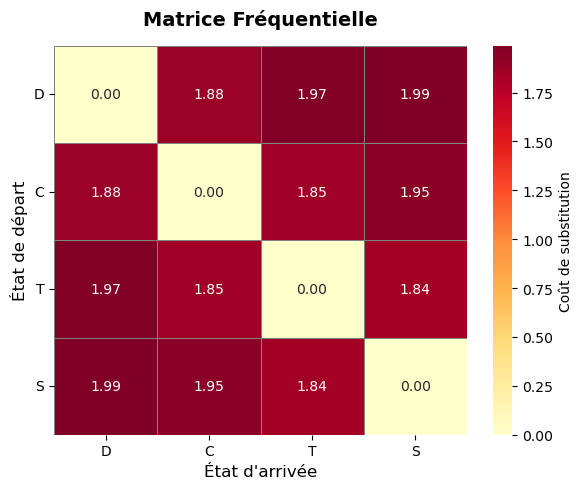

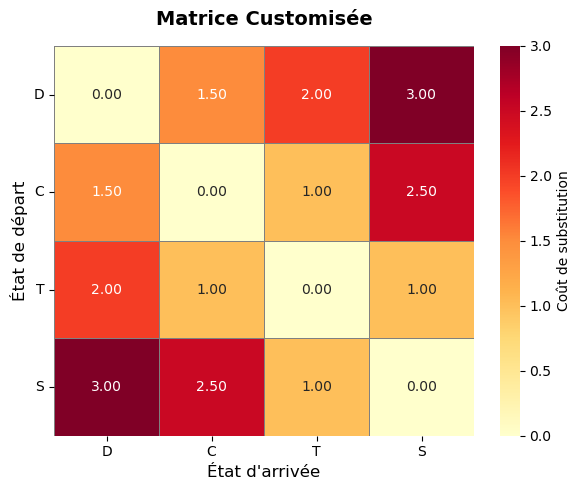

<Axes: title={'center': 'Matrice Customisée'}, xlabel="État d'arrivée", ylabel='État de départ'>

In [8]:
print("Affichage des Heatmaps :")
plot_cost_matrix(cost_matrix_constant, title="Matrice Constante")
plot_cost_matrix(cost_matrix_frequency, title="Matrice Fréquentielle")
plot_cost_matrix(cost_matrix_custom, title="Matrice Customisée")

## 3.1. Distance de Hamming

In [9]:
distance_matrix_ham = tca.compute_distance_matrix(tca.data,metric='hamming', substitution_cost_matrix=cost_matrix_frequency)
print("Distance matrix (Hamming):\n",distance_matrix_ham)

INFO:root:Calculating distance matrix using metric: hamming...
INFO:root:Time taken for computation: 0.01 seconds


Distance matrix (Hamming):
 [[0.         0.83673469 0.87755102 ... 0.97959184 0.85714286 0.97959184]
 [0.83673469 0.         0.95918367 ... 0.97959184 0.89795918 0.95918367]
 [0.87755102 0.95918367 0.         ... 0.97959184 0.89795918 0.97959184]
 ...
 [0.97959184 0.97959184 0.97959184 ... 0.         0.97959184 0.97959184]
 [0.85714286 0.89795918 0.89795918 ... 0.97959184 0.         0.97959184]
 [0.97959184 0.95918367 0.97959184 ... 0.97959184 0.97959184 0.        ]]


## 3.2. Distance de Levenshtein

In [10]:
distance_matrix_lev = tca.compute_distance_matrix(tca.data,metric='levenshtein', substitution_cost_matrix=cost_matrix_frequency)
print("Distance matrix (Levenshtein):\n",distance_matrix_lev)

INFO:root:Calculating distance matrix using metric: levenshtein...
100%|██████████| 292/292 [00:00<00:00, 446.16it/s]
INFO:root:Time taken for computation: 0.69 seconds


Distance matrix (Levenshtein):
 [[ 0.  5.  6. ... 11. 21. 10.]
 [ 5.  0. 11. ... 12. 23. 11.]
 [ 6. 11.  0. ...  9. 21.  8.]
 ...
 [11. 12.  9. ...  0. 27.  1.]
 [21. 23. 21. ... 27.  0. 26.]
 [10. 11.  8. ...  1. 26.  0.]]


## 3.3. Distance Optimal Matching

In [11]:
distance_matrix_OM = tca.compute_distance_matrix(tca.data,metric='optimal_matching', substitution_cost_matrix=cost_matrix_frequency)
print("Distance matrix (Optimal Matching):\n",distance_matrix_OM)

INFO:root:Calculating distance matrix using metric: optimal_matching...


Calculated indel cost: 0.9944834080063996 (from max sub_cost: 1.9889668160127991)
substitution cost matrix: 
           D         C         T         S
D  0.000000  1.877628  1.974524  1.988967
C  1.877628  0.000000  1.853099  1.948162
T  1.974524  1.853099  0.000000  1.841050
S  1.988967  1.948162  1.841050  0.000000


100%|██████████| 292/292 [00:25<00:00, 11.34it/s]
INFO:root:Time taken for computation: 25.76 seconds


Distance matrix (Optimal Matching):
 [[0.         0.65423047 0.79162329 ... 0.91160979 0.84048521 0.82873617]
 [0.65423047 0.         1.38495966 ... 0.91798468 1.07614528 0.84148596]
 [0.79162329 1.38495966 0.         ... 0.89503507 0.84270952 0.79558673]
 ...
 [0.91160979 0.91798468 0.89503507 ... 0.         0.95896614 0.4972417 ]
 [0.84048521 1.07614528 0.84270952 ... 0.95896614 0.         0.92344888]
 [0.82873617 0.84148596 0.79558673 ... 0.4972417  0.92344888 0.        ]]


## 3.4. Distance Dynamic Time Warping (DTW)

In [12]:
distance_matrix_dtw = tca.compute_distance_matrix(tca.data,metric='dtw')
print("Distance matrix (DTW):\n",distance_matrix_dtw)

INFO:root:Calculating distance matrix using metric: dtw...
100%|██████████| 292/292 [00:27<00:00, 10.71it/s]
INFO:root:Time taken for computation: 27.27 seconds


Distance matrix (DTW):
 [[0.         0.15384615 0.         ... 0.16666667 0.35174492 0.16666667]
 [0.15384615 0.         0.21757132 ... 0.         0.42857143 0.        ]
 [0.         0.21757132 0.         ... 0.28284271 0.29233403 0.28284271]
 ...
 [0.16666667 0.         0.28284271 ... 0.         0.42857143 0.        ]
 [0.35174492 0.42857143 0.29233403 ... 0.42857143 0.         0.42857143]
 [0.16666667 0.         0.28284271 ... 0.         0.42857143 0.        ]]


## 3.5. Distance Global Alignment Kernel (GAK)

In [13]:
distance_matrix_gak = tca.compute_distance_matrix(tca.data,metric='gak')
print("Distance matrix (GAK):\n",distance_matrix_gak)

INFO:root:Calculating distance matrix using metric: gak...
100%|██████████| 292/292 [00:21<00:00, 13.86it/s]
INFO:root:Time taken for computation: 21.08 seconds


Distance matrix (GAK):
 [[0.00000000e+00 1.72997961e-03 1.08383042e-03 ... 1.32627766e-06
  2.87735690e-33 1.58819896e-05]
 [1.72997961e-03 0.00000000e+00 1.67724702e-06 ... 4.84958760e-06
  1.53063409e-41 6.99977676e-05]
 [1.08383042e-03 1.67724702e-06 0.00000000e+00 ... 2.36248590e-07
  1.91309445e-24 1.97533666e-06]
 ...
 [1.32627766e-06 4.84958760e-06 2.36248590e-07 ... 0.00000000e+00
  8.87011222e-47 2.88675135e-01]
 [2.87735690e-33 1.53063409e-41 1.91309445e-24 ... 8.87011222e-47
  0.00000000e+00 1.78767123e-45]
 [1.58819896e-05 6.99977676e-05 1.97533666e-06 ... 2.88675135e-01
  1.78767123e-45 0.00000000e+00]]


# 4. Clustering

## 4.1. Distance de Hamming

### 4.1.1. CAH
On fait d'abord une classification Ascendante Hiérarchique pour savoir quel nombre de clusters serait le mieux 

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


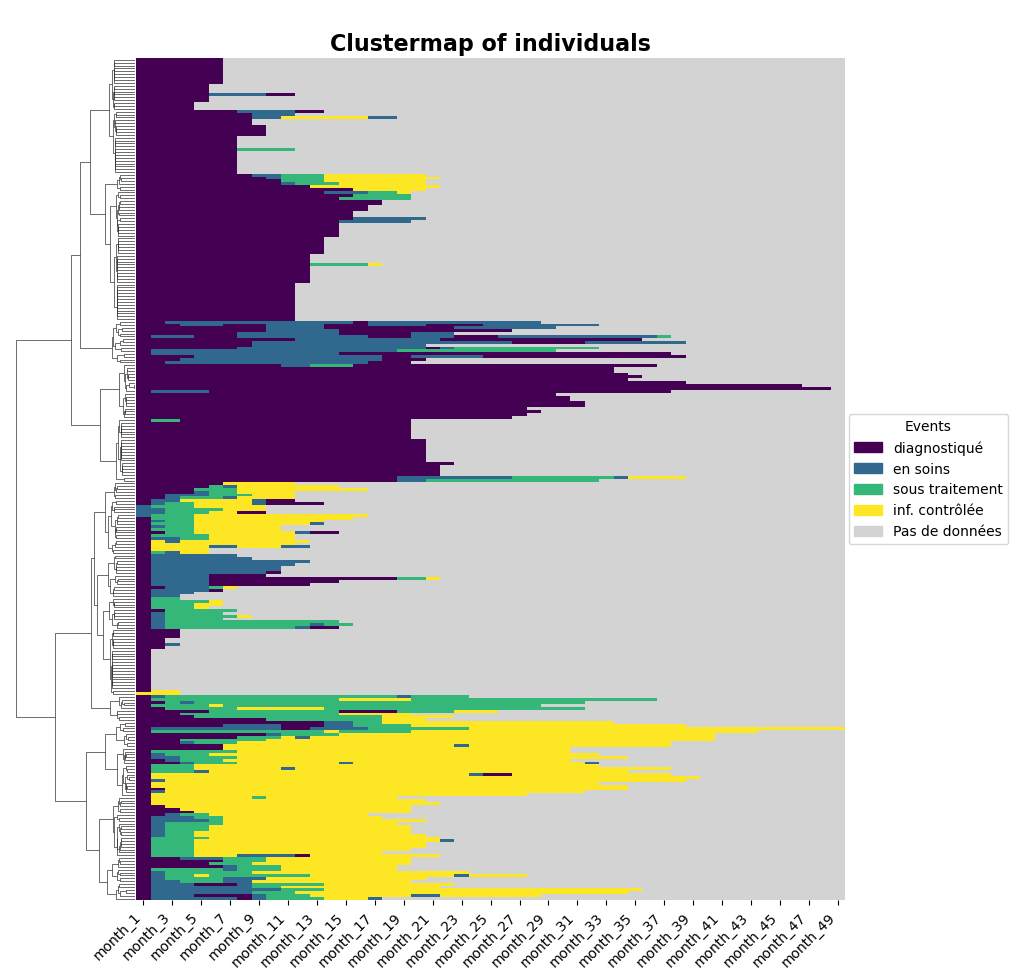

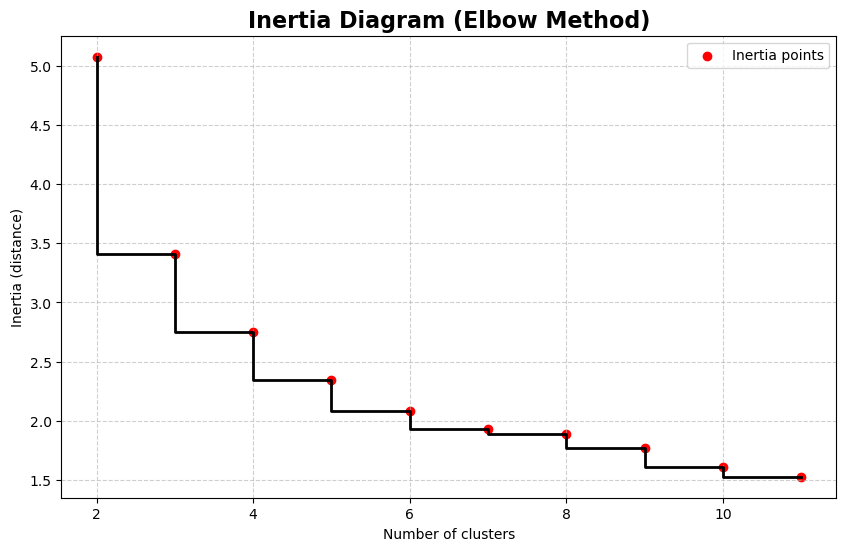

In [14]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_ham = tca.hierarchical_clustering(distance_matrix_ham)
#tca.plot_dendrogram(linkage_matrix_ham)
tca.plot_clustermap(tca.data,linkage_matrix_ham)
tca.plot_inertia(linkage_matrix_ham)

On teste pour 3 clusters.

### 4.1.2. K-medoids

In [15]:
kmedoids_labels_ham, medoid_indices_ham, inertia_med_ham = tca.kmedoids_clustering(distance_matrix_ham, num_clusters=3,method='fasterpam')
print("kmedoids_labels (Hamming) :", np.unique(kmedoids_labels_ham))
print("medoid_indices (Hamming) :", medoid_indices_ham)
print("inertia (Hamming) :", inertia_med_ham)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Hamming) : [1 2 3]
medoid_indices (Hamming) : [156 124  11]
inertia (Hamming) : 210.61224489795936


### 4.1.3. Heatmaps 
Actuellement, la fonction `plot_cluster_heatmaps` (dans le module plotting.py) crée une nouvelle figure à chaque appel. Il serait interessant de la modifier pour qu'elle accepte un argument ax (un axe Matplotlib). Cela permettra d'afficher plusieurs heatmaps sur une seule et même grille (subplots) pour la comparaison des modèles.

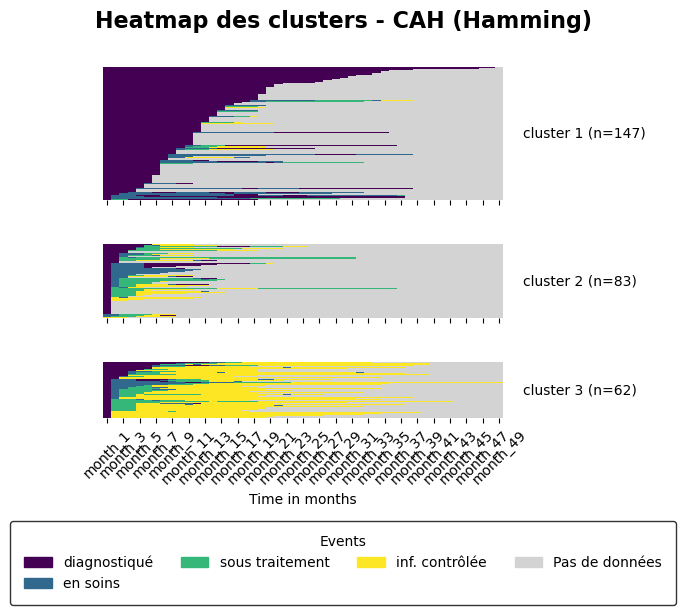

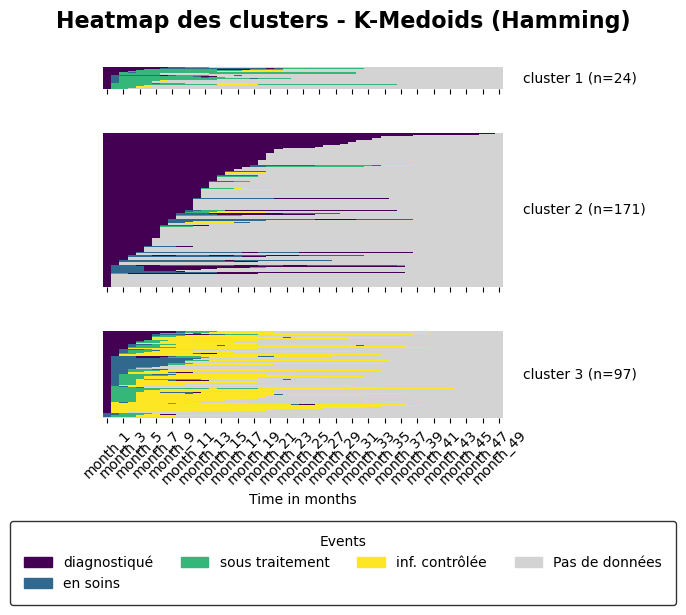

In [16]:
clusters_ham = tca.assign_clusters(linkage_matrix_ham, num_clusters=3)

methodes_clustering_ham = {
    "CAH (Hamming)": clusters_ham,
    "K-Medoids (Hamming)": kmedoids_labels_ham,
}

for titre, labels in methodes_clustering_ham.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

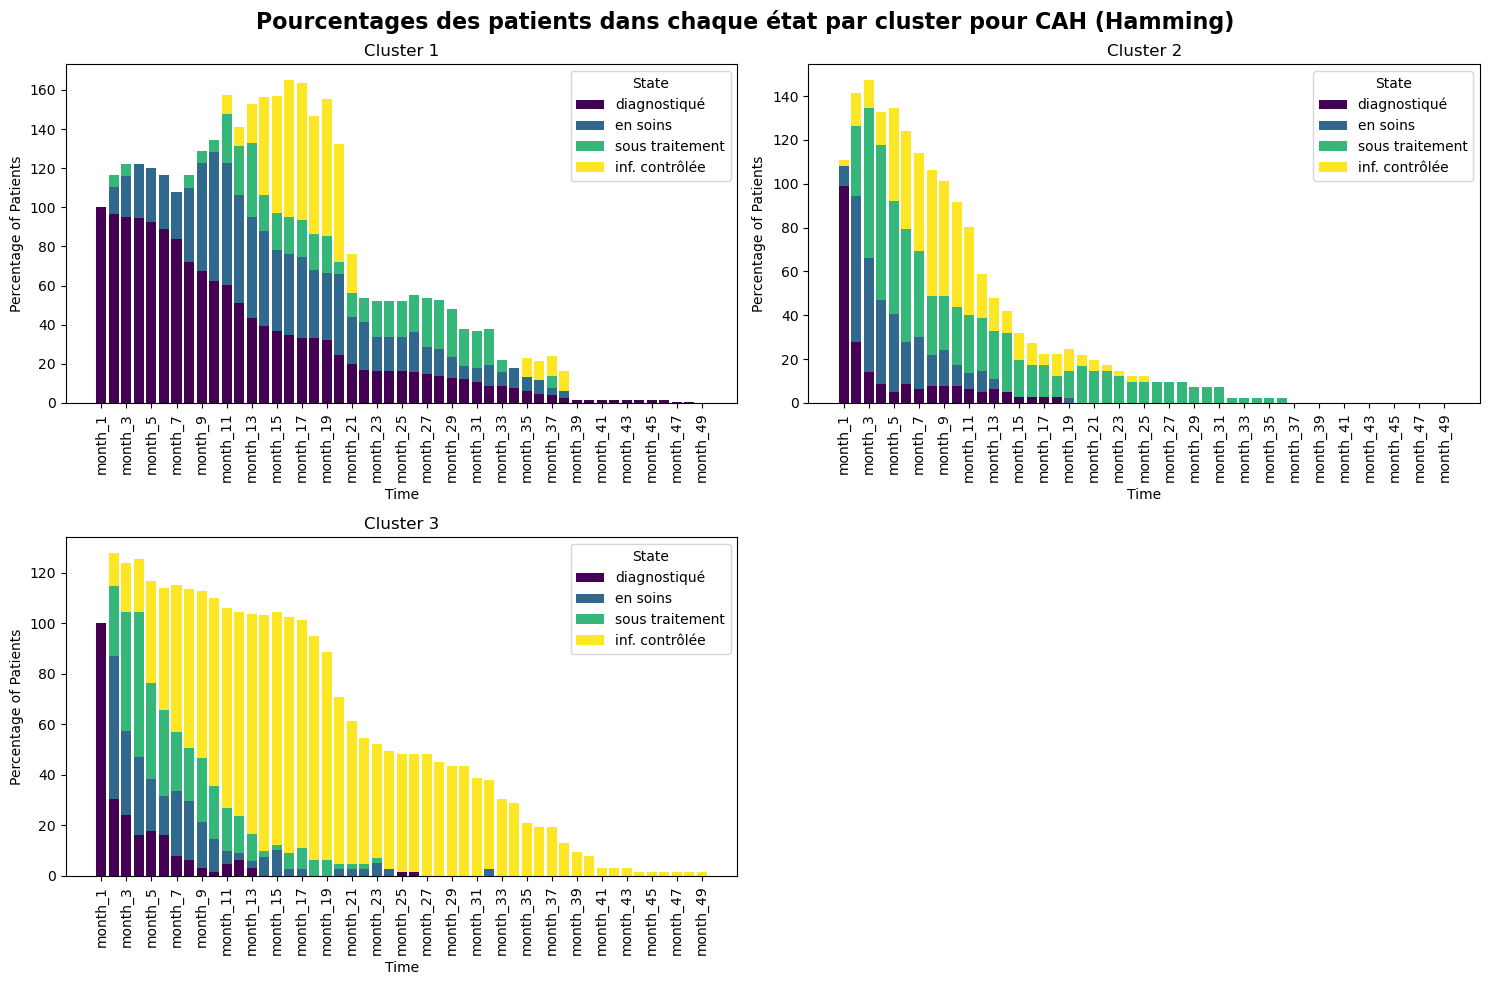

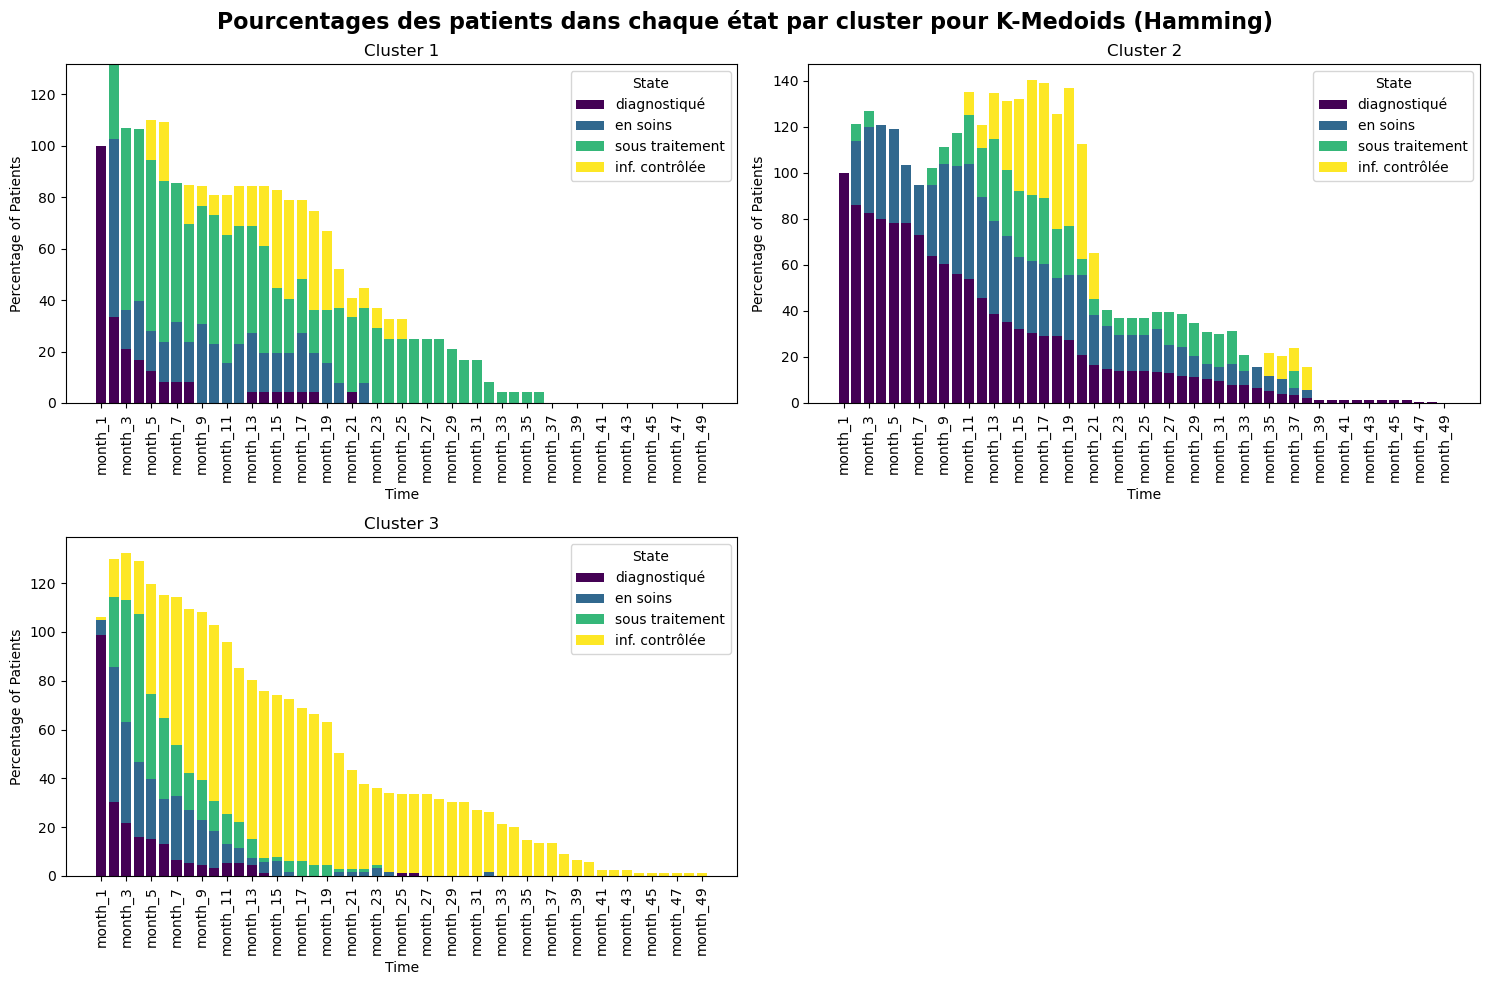

In [17]:
tca.bar_treatment_percentage(clusters=clusters_ham, title="Pourcentages des patients dans chaque état par cluster pour CAH (Hamming)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_ham, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (Hamming)")

## 4.2. Distance de Levenshtein

### 4.2.1. CAH

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


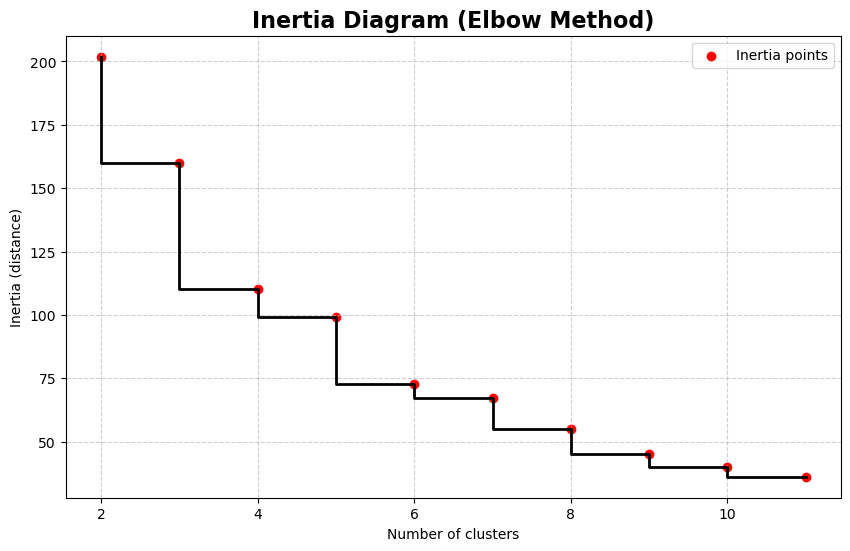

In [18]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_lev = tca.hierarchical_clustering(distance_matrix_lev)
#tca.plot_dendrogram(linkage_matrix_lev)
#tca.plot_clustermap(tca.data,linkage_matrix_lev)
tca.plot_inertia(linkage_matrix_lev)

### 4.2.2. K-medoids

In [19]:
kmedoids_labels_lev, medoid_indices_lev, inertia_med_lev = tca.kmedoids_clustering(distance_matrix_lev, num_clusters=3,method='fasterpam')
print("kmedoids_labels (Levenshtein) :", np.unique(kmedoids_labels_lev))
print("medoid_indices (Levenshtein) :", medoid_indices_lev)
print("inertia (Levenshtein) :", inertia_med_lev)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Levenshtein) : [1 2 3]
medoid_indices (Levenshtein) : [  8  34 102]
inertia (Levenshtein) : 2256.0


### 4.2.3. Heatmaps

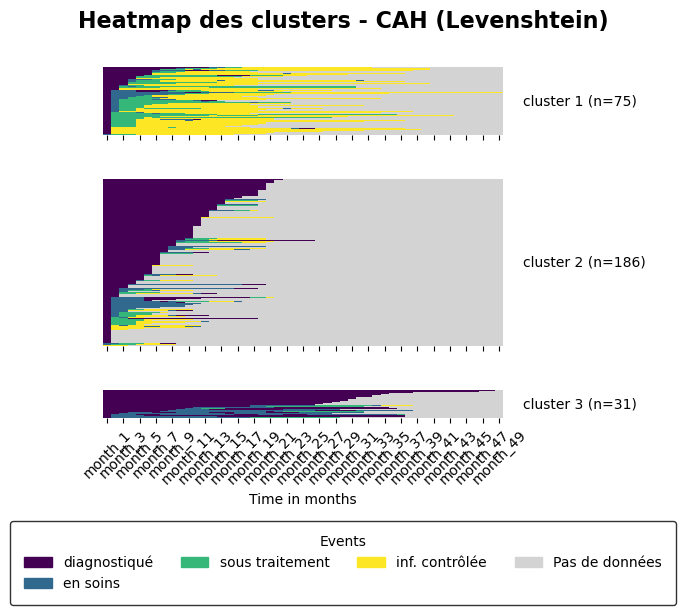

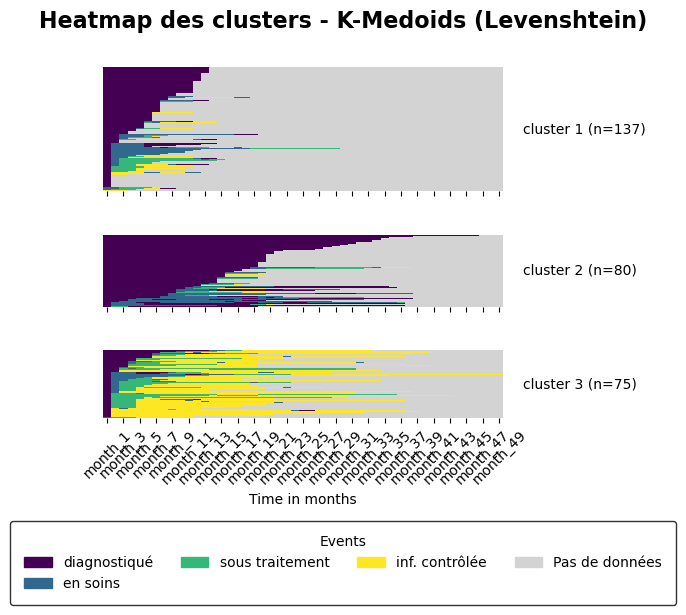

In [20]:
clusters_lev = tca.assign_clusters(linkage_matrix_lev, num_clusters=3)

methodes_clustering_lev = {
    "CAH (Levenshtein)": clusters_lev,
    "K-Medoids (Levenshtein)": kmedoids_labels_lev,
}

for titre, labels in methodes_clustering_lev.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

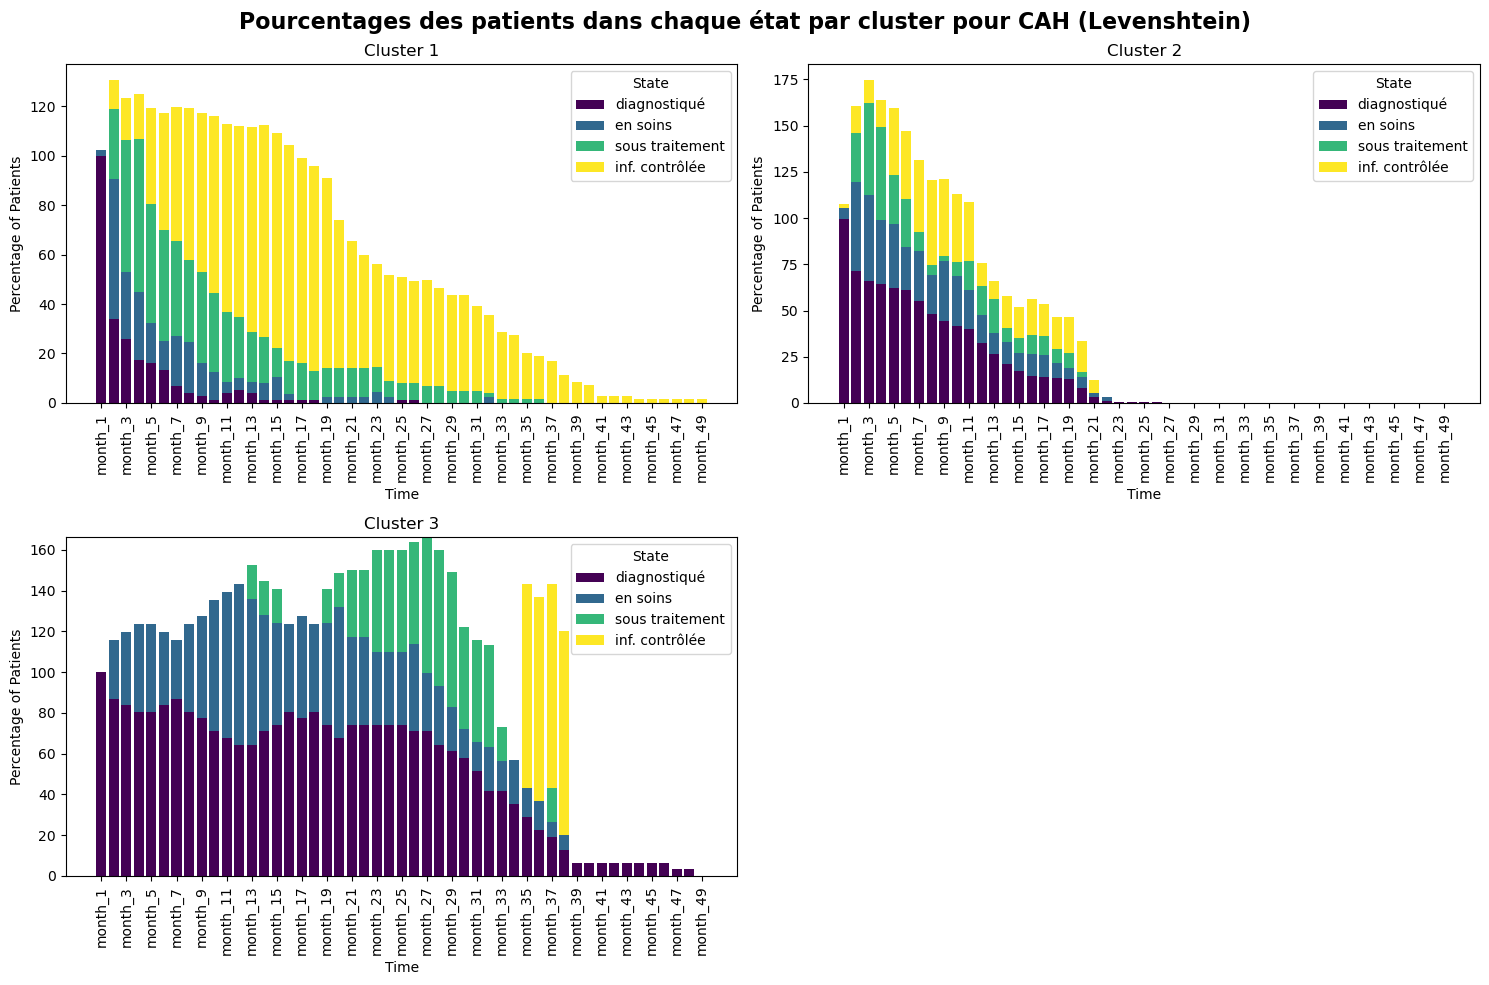

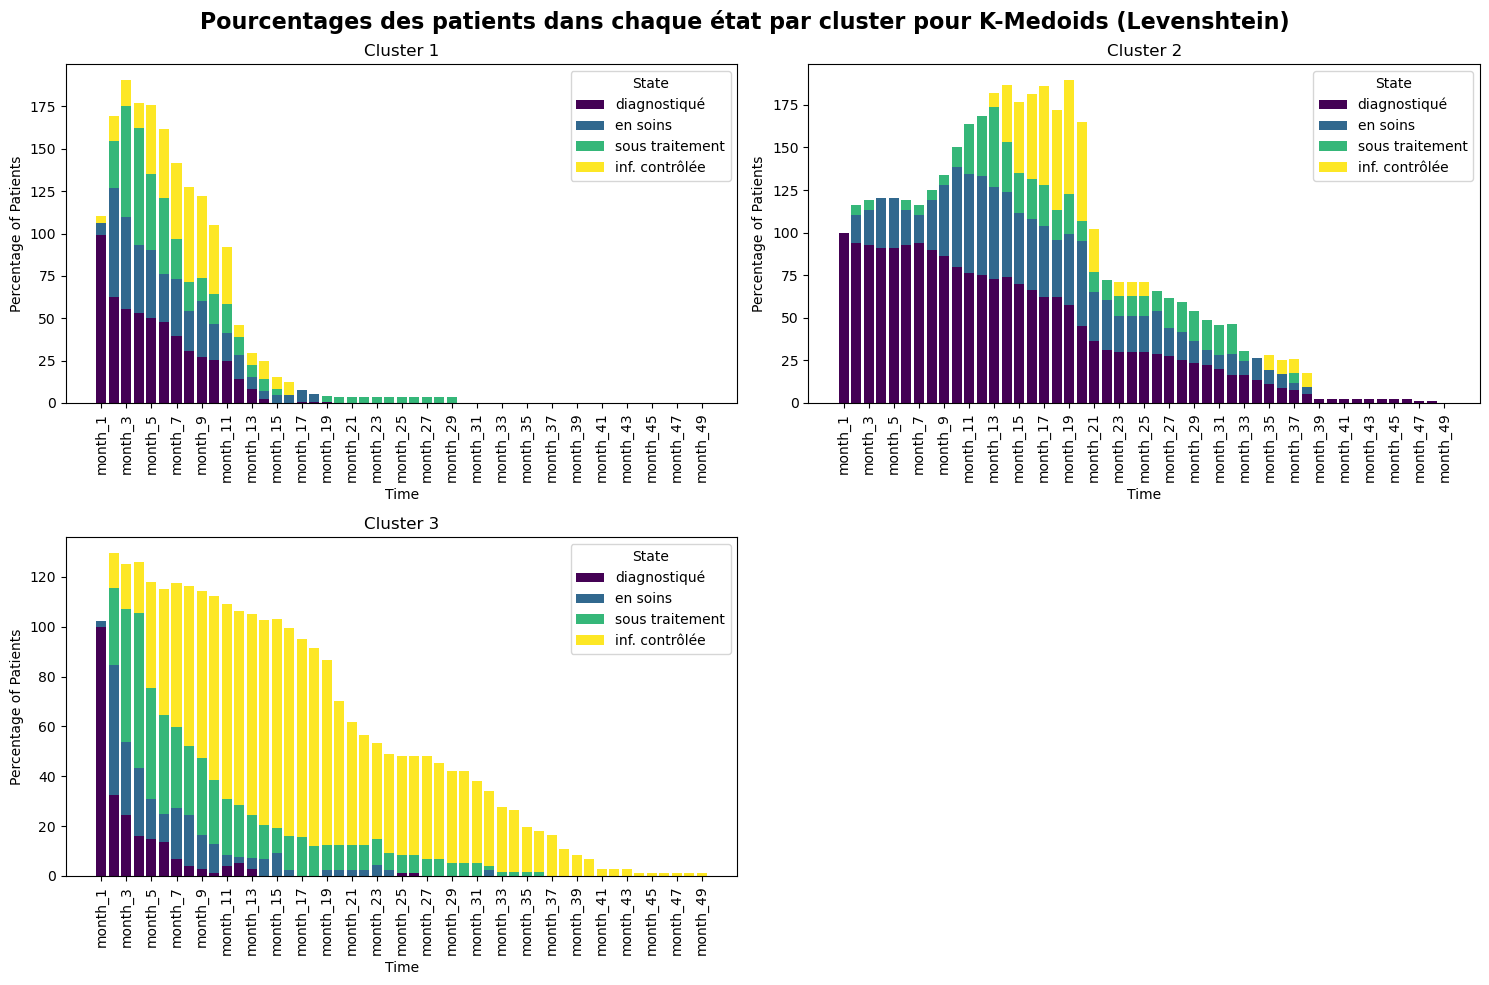

In [21]:
tca.bar_treatment_percentage(clusters=clusters_lev, title="Pourcentages des patients dans chaque état par cluster pour CAH (Levenshtein)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_lev, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (Levenshtein)")

## 4.3. Distance Optimal Matching

#### 4.3.1. CAH

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


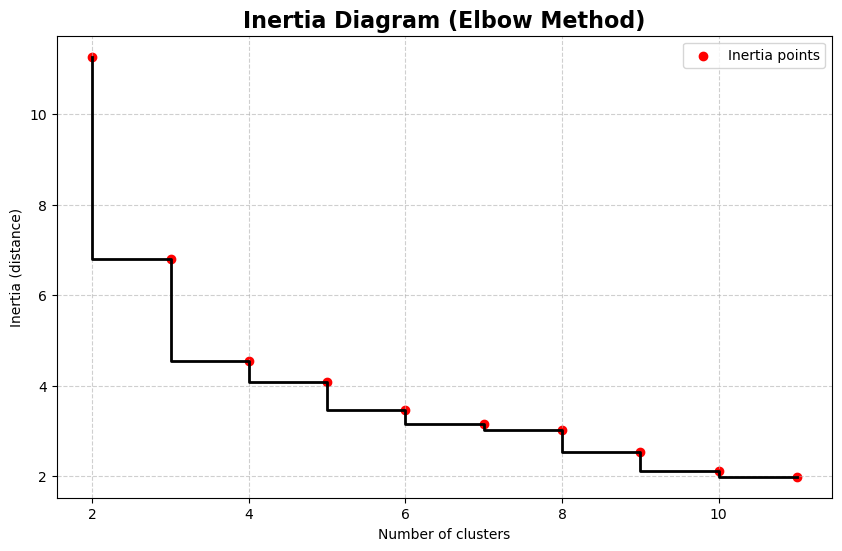

In [22]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_OM = tca.hierarchical_clustering(distance_matrix_OM)
#tca.plot_dendrogram(linkage_matrix_OM)
#tca.plot_clustermap(tca.data,linkage_matrix_OM)
tca.plot_inertia(linkage_matrix_OM)

3 clusters ici aussi

### 4.3.2. K-medoids

In [23]:
kmedoids_labels_OM, medoid_indices_OM, inertia_med_OM = tca.kmedoids_clustering(distance_matrix_OM, num_clusters=3,method='fasterpam')
print("kmedoids_labels (Optimal Matching) :", np.unique(kmedoids_labels_OM))
print("medoid_indices (Optimal Matching) :", medoid_indices_OM)
print("inertia (Optimal Matching) :", inertia_med_OM)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (Optimal Matching) : [1 2 3]
medoid_indices (Optimal Matching) : [177 287  96]
inertia (Optimal Matching) : 135.80015654556607


### 4.3.3. Comparaison

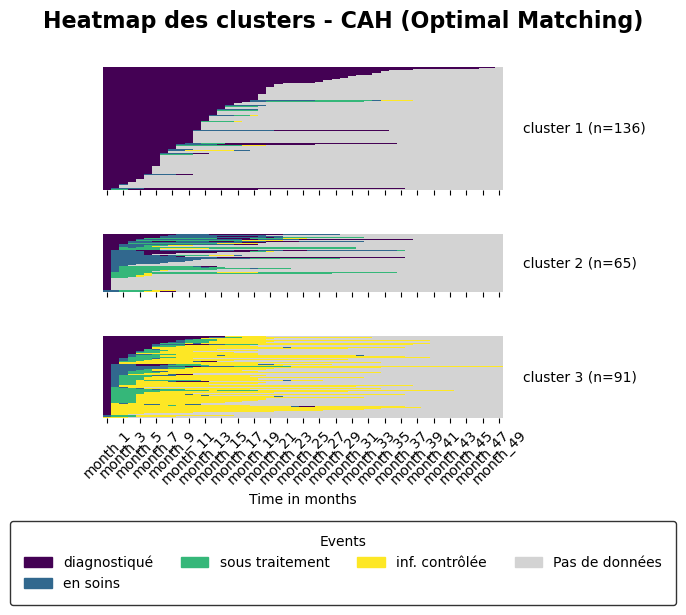

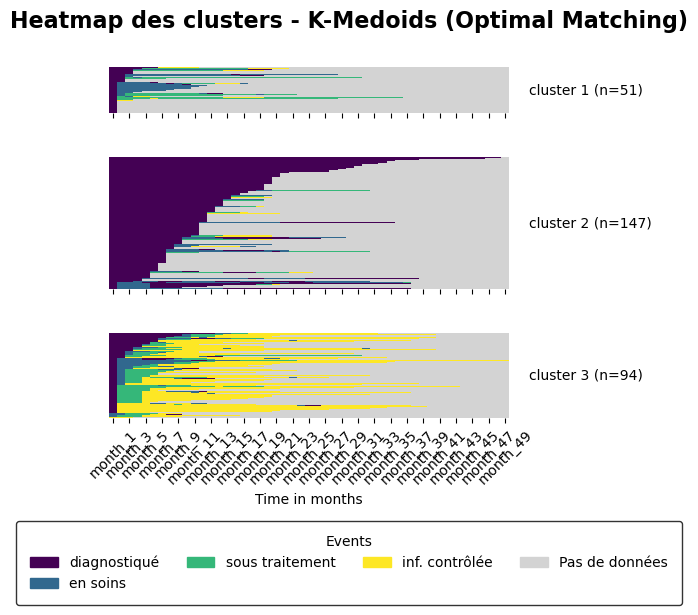

In [24]:
clusters_OM = tca.assign_clusters(linkage_matrix_OM, num_clusters=3)

methodes_clustering_OM = {
    "CAH (Optimal Matching)": clusters_OM,
    "K-Medoids (Optimal Matching)": kmedoids_labels_OM,
}

for titre, labels in methodes_clustering_OM.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

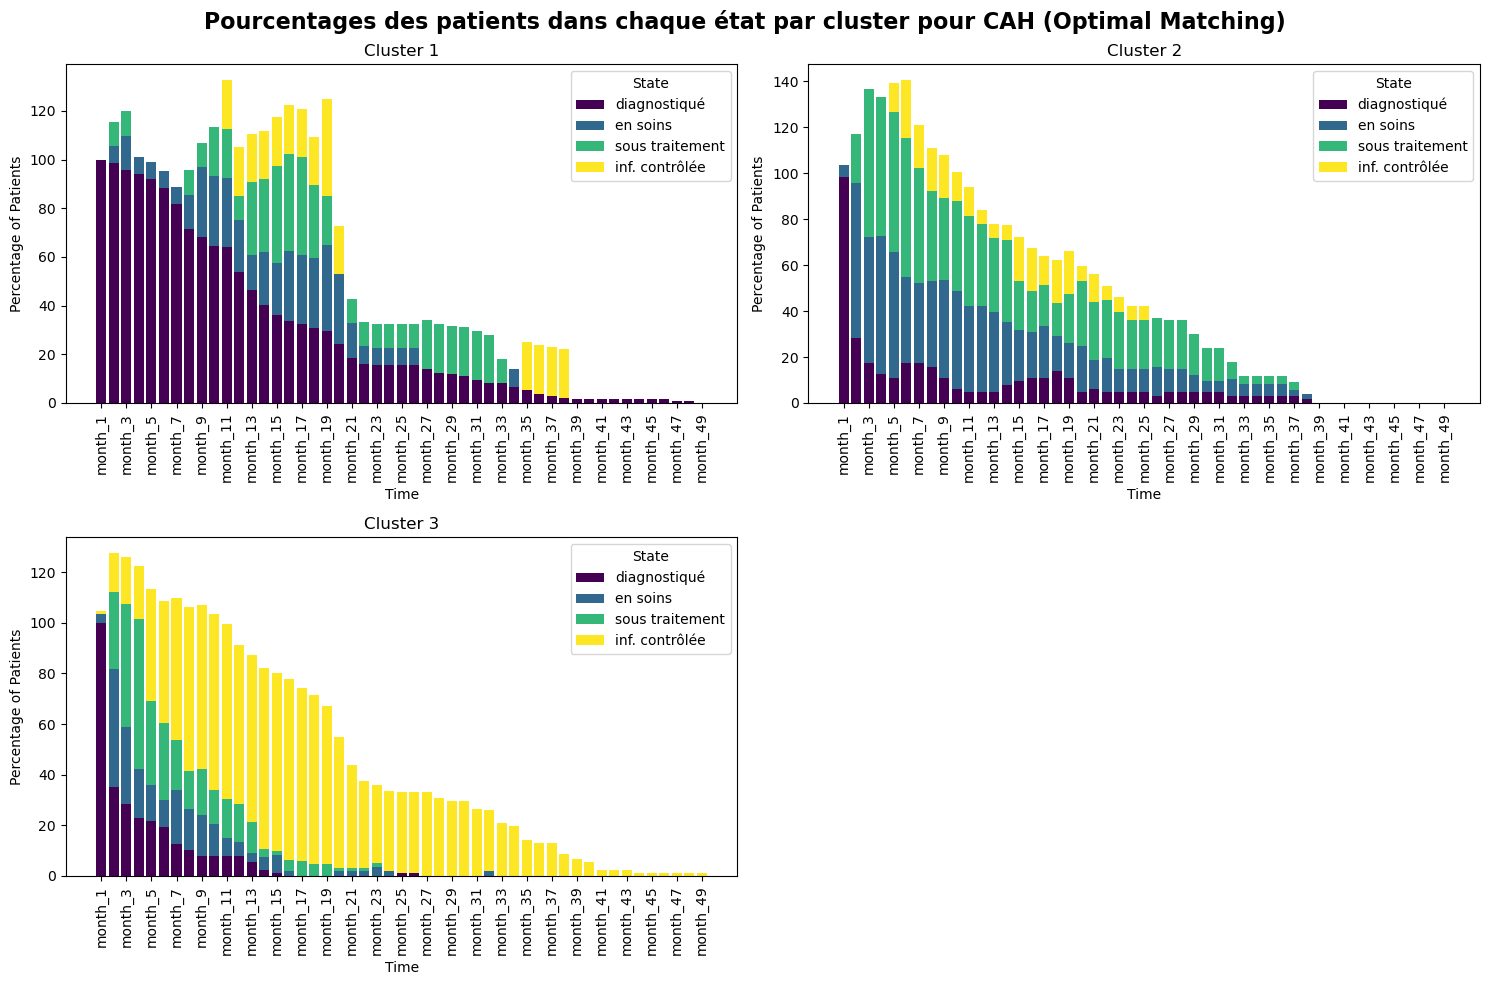

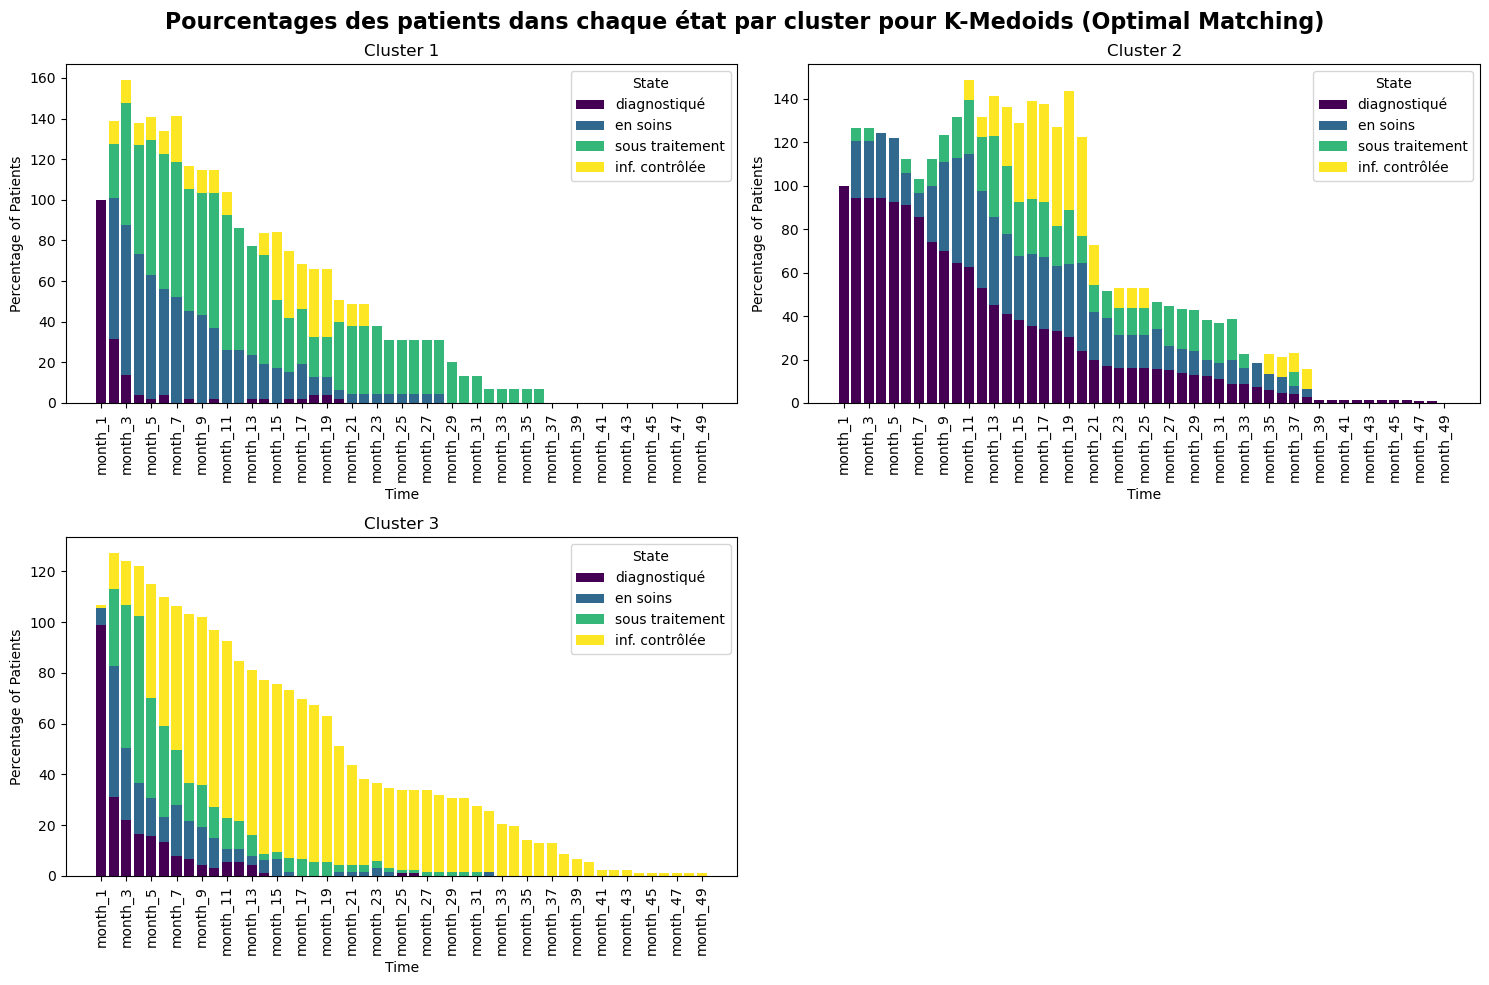

In [25]:
tca.bar_treatment_percentage(clusters=clusters_OM, title="Pourcentages des patients dans chaque état par cluster pour CAH (Optimal Matching)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_OM, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (Optimal Matching)")

## 4.4. Distance de DTW

### 4.4.1. CAH 

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


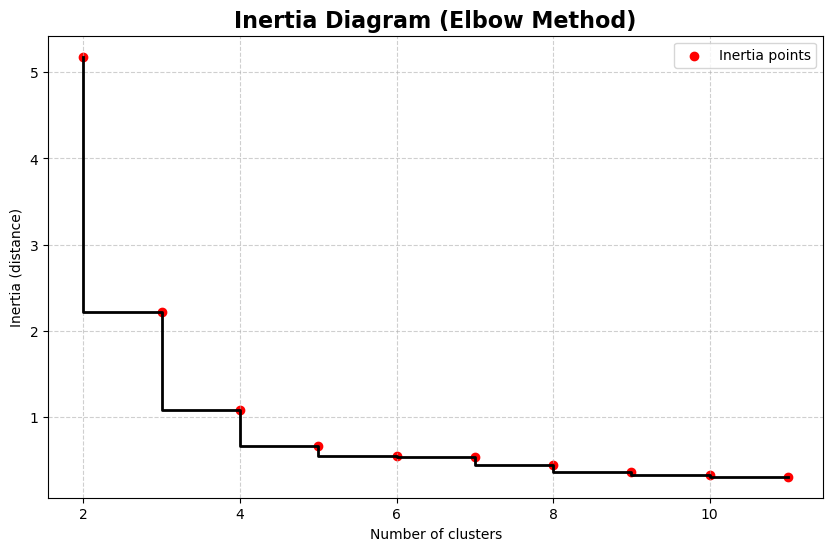

In [26]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_dtw = tca.hierarchical_clustering(distance_matrix_dtw)
#tca.plot_dendrogram(linkage_matrix_dtw)
#tca.plot_clustermap(tca.data,linkage_matrix_dtw)
tca.plot_inertia(linkage_matrix_dtw)

### 4.4.2. K-medoids

In [27]:
kmedoids_labels_dtw, medoid_indices_dtw, inertia_med_dtw = tca.kmedoids_clustering(distance_matrix_dtw, num_clusters=3,method='fasterpam')
print("kmedoids_labels (DTW) :", np.unique(kmedoids_labels_dtw))
print("medoid_indices (DTW) :", medoid_indices_dtw)
print("inertia (DTW) :", inertia_med_dtw)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (DTW) : [1 2 3]
medoid_indices (DTW) : [ 28 141  37]
inertia (DTW) : 6.879316158126268


### 4.4.3. Heatmaps

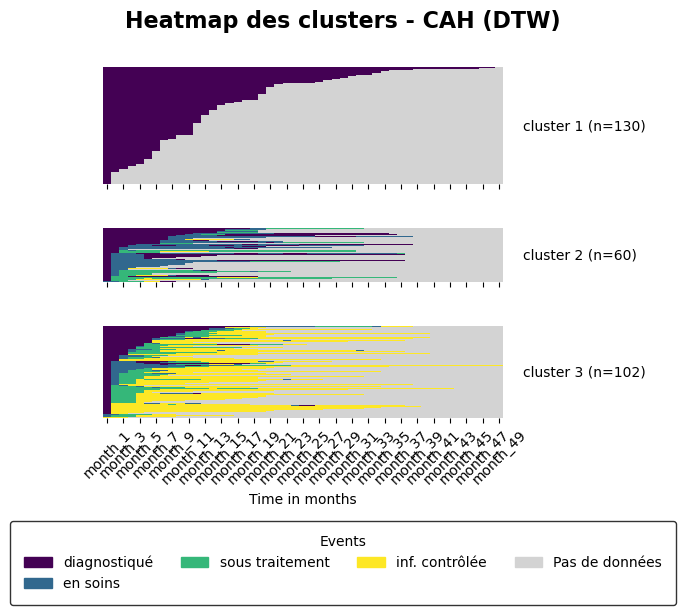

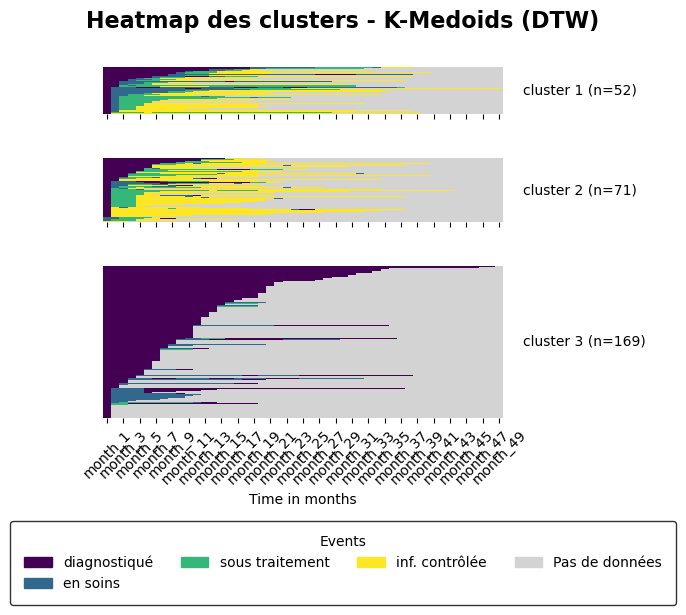

In [28]:
clusters_dtw = tca.assign_clusters(linkage_matrix_dtw, num_clusters=3)

methodes_clustering_dtw = {
    "CAH (DTW)": clusters_dtw,
    "K-Medoids (DTW)": kmedoids_labels_dtw,
}

for titre, labels in methodes_clustering_dtw.items():
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

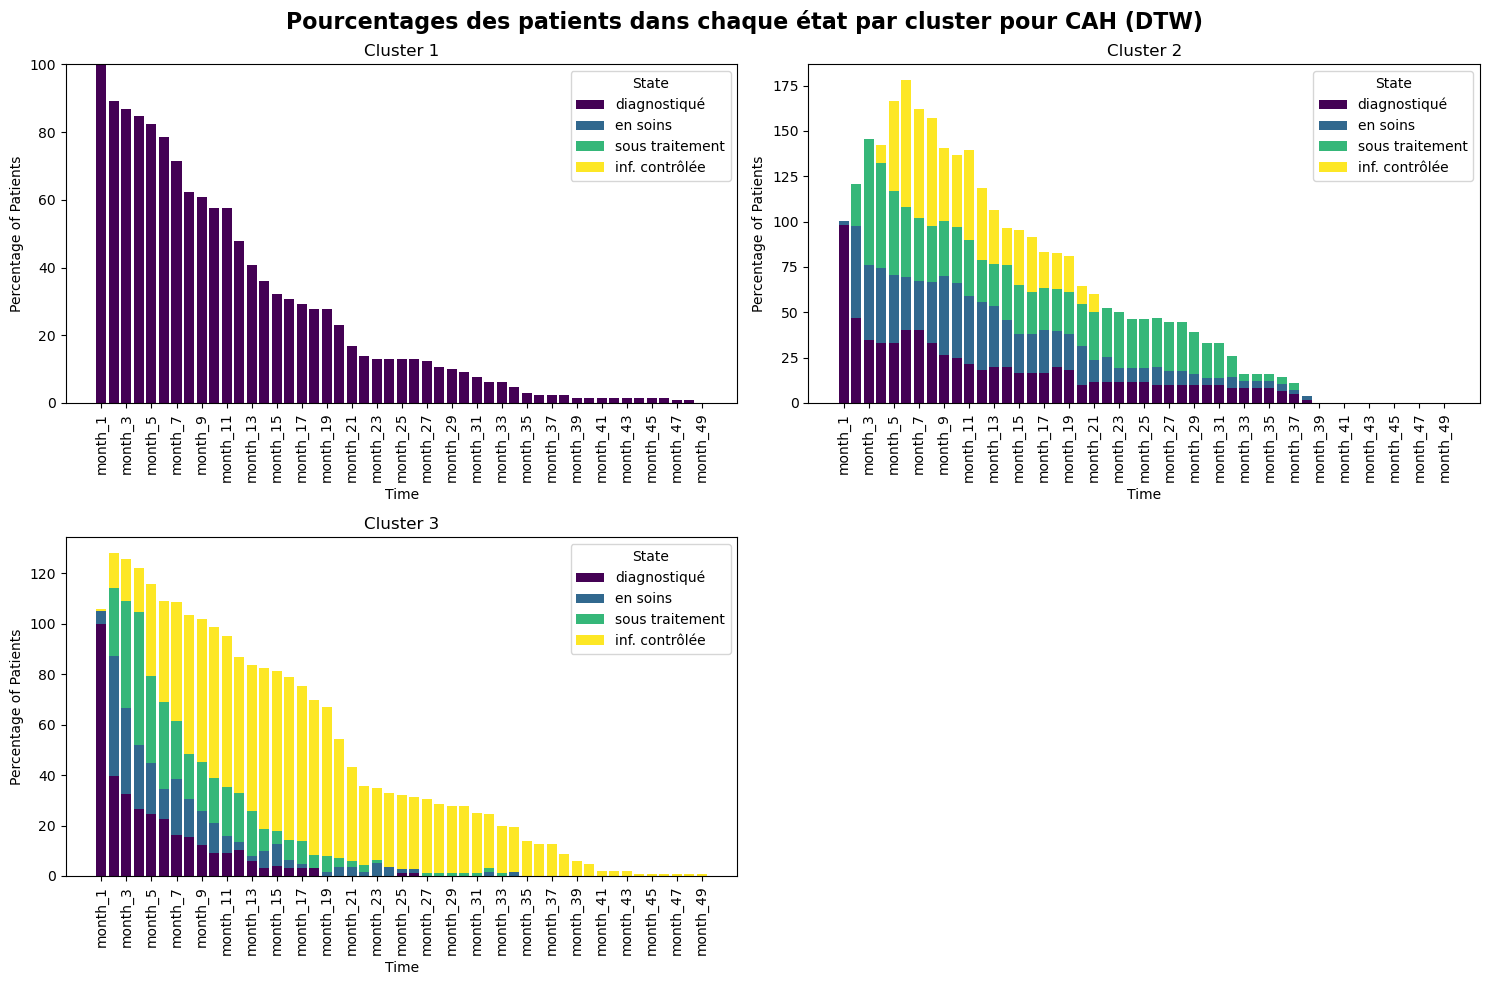

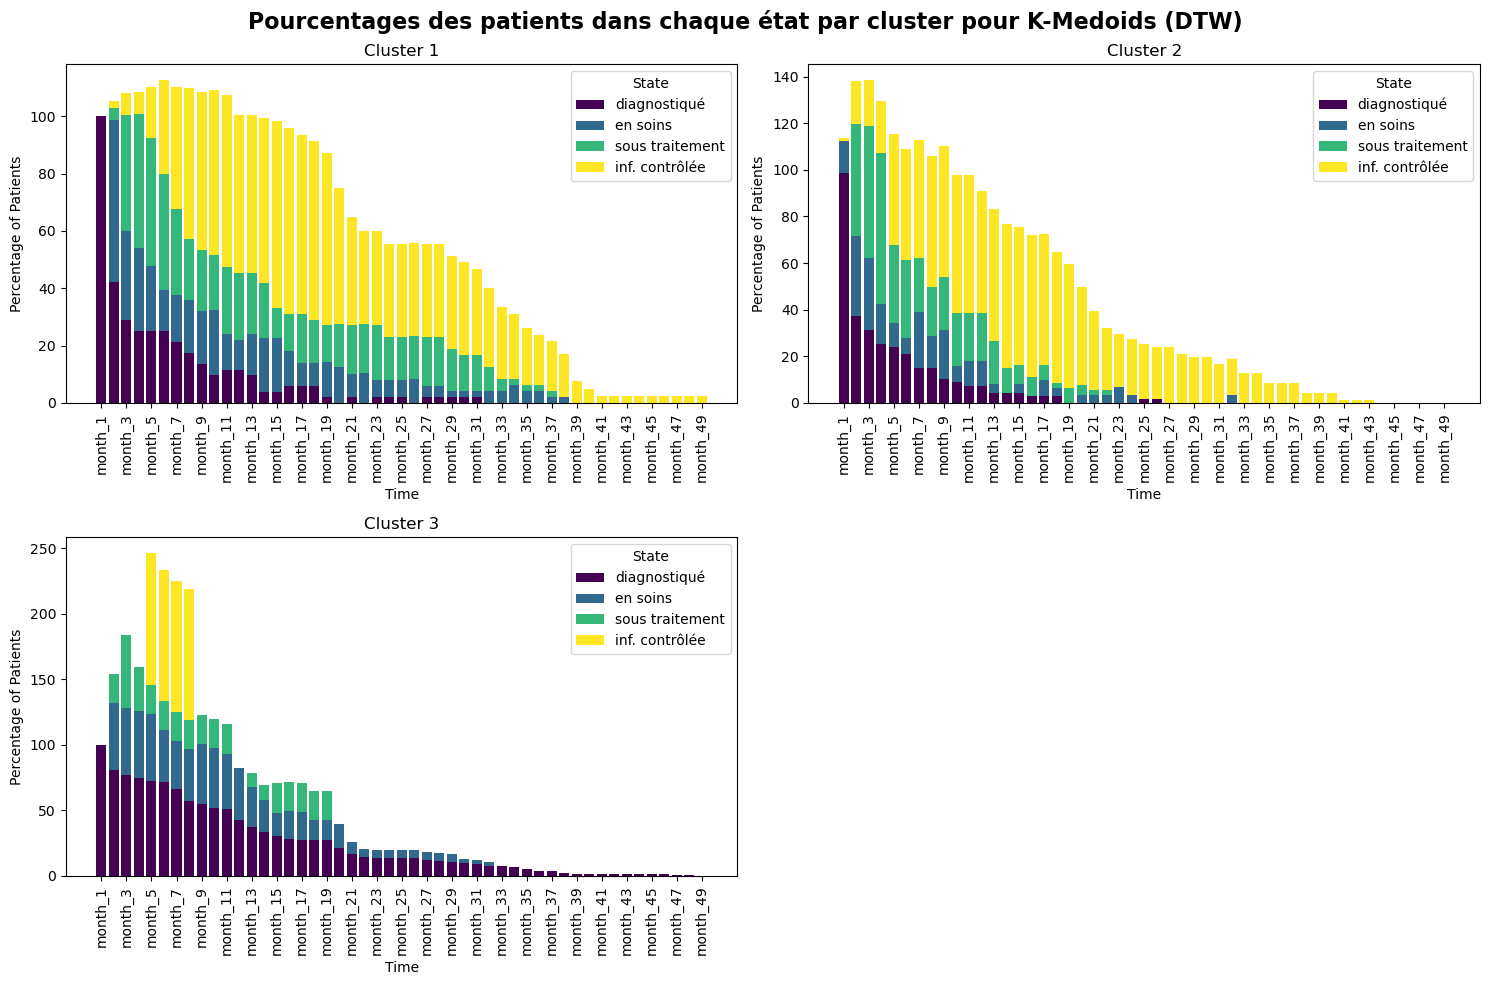

In [29]:
tca.bar_treatment_percentage(clusters=clusters_dtw, title="Pourcentages des patients dans chaque état par cluster pour CAH (DTW)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_dtw, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (DTW)")

## 4.5. Distance GAK

### 4.5.1. CAH

INFO:root:Computing the linkage matrix using method: ward...
INFO:root:Linkage matrix computed successfully


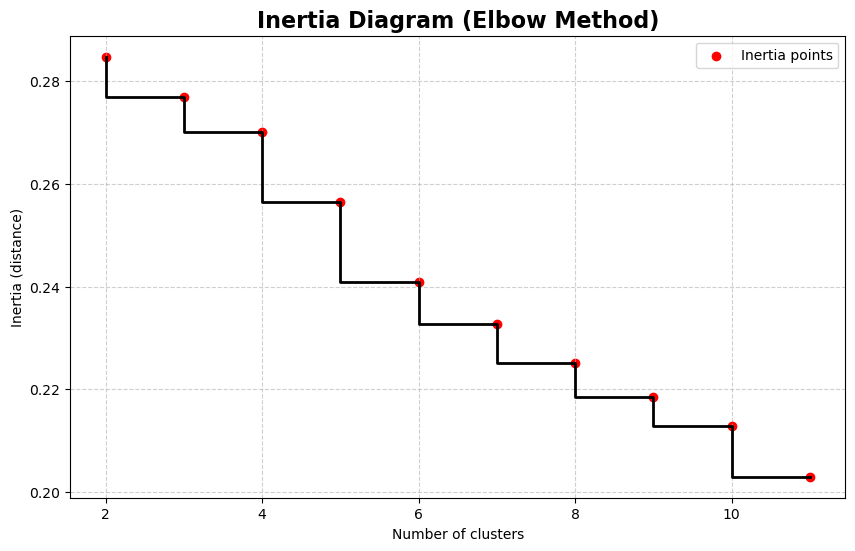

In [30]:
# CAH (Classification Ascendante Hiérarchique)
linkage_matrix_gak = tca.hierarchical_clustering(distance_matrix_gak)
#tca.plot_dendrogram(linkage_matrix_gak)
#tca.plot_clustermap(tca.data,linkage_matrix_gak)
tca.plot_inertia(linkage_matrix_gak)

### 4.5.2. K-medoids

In [31]:
kmedoids_labels_gak, medoid_indices_gak, inertia_med_gak = tca.kmedoids_clustering(distance_matrix_gak, num_clusters=3,method='fasterpam')
print("kmedoids_labels (GAK) :", np.unique(kmedoids_labels_gak))
print("medoid_indices (GAK) :", medoid_indices_gak)
print("inertia (GAK) :", inertia_med_gak)

INFO:root:Performing K-Medoids clustering with 3 clusters...
INFO:root:K-Medoids clustering completed.


kmedoids_labels (GAK) : [1 2 3]
medoid_indices (GAK) : [281  16  37]
inertia (GAK) : 1.6105304022545025e-21


### 4.5.3. Comparaison

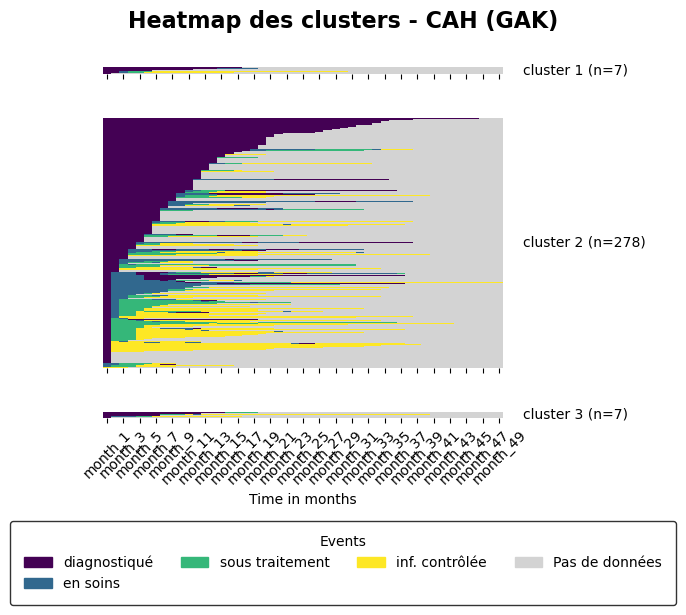

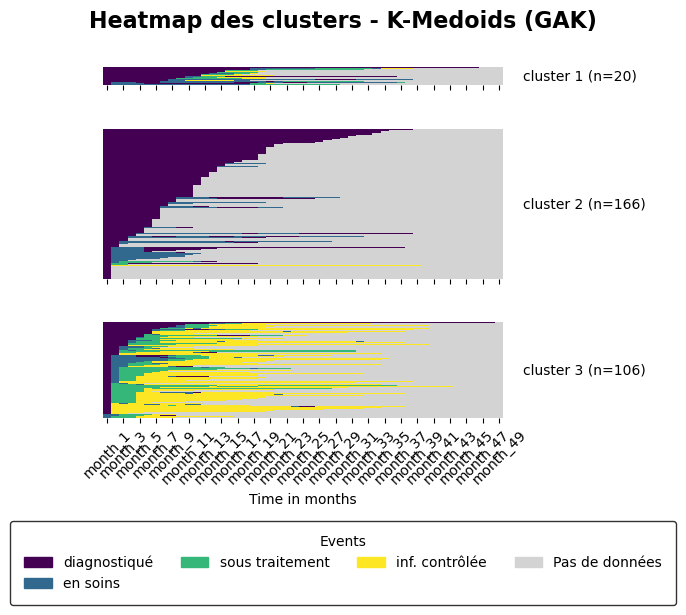

In [32]:
clusters_gak = tca.assign_clusters(linkage_matrix_gak, num_clusters=3)

methodes_clustering_gak = {
    "CAH (GAK)": clusters_gak,
    "K-Medoids (GAK)": kmedoids_labels_gak,
}

for titre, labels in methodes_clustering_gak.items():    
    tca.plot_cluster_heatmaps(tca.data, labels, sorted=True, title=f"Heatmap des clusters - {titre}")

Pour cette distance, avec CAH, on a le cluster 2 qui a presque tous les patients, et les clusters 1 et 3 qui n'en n'ont que très peu, il ne peut pas permettre de généraliser

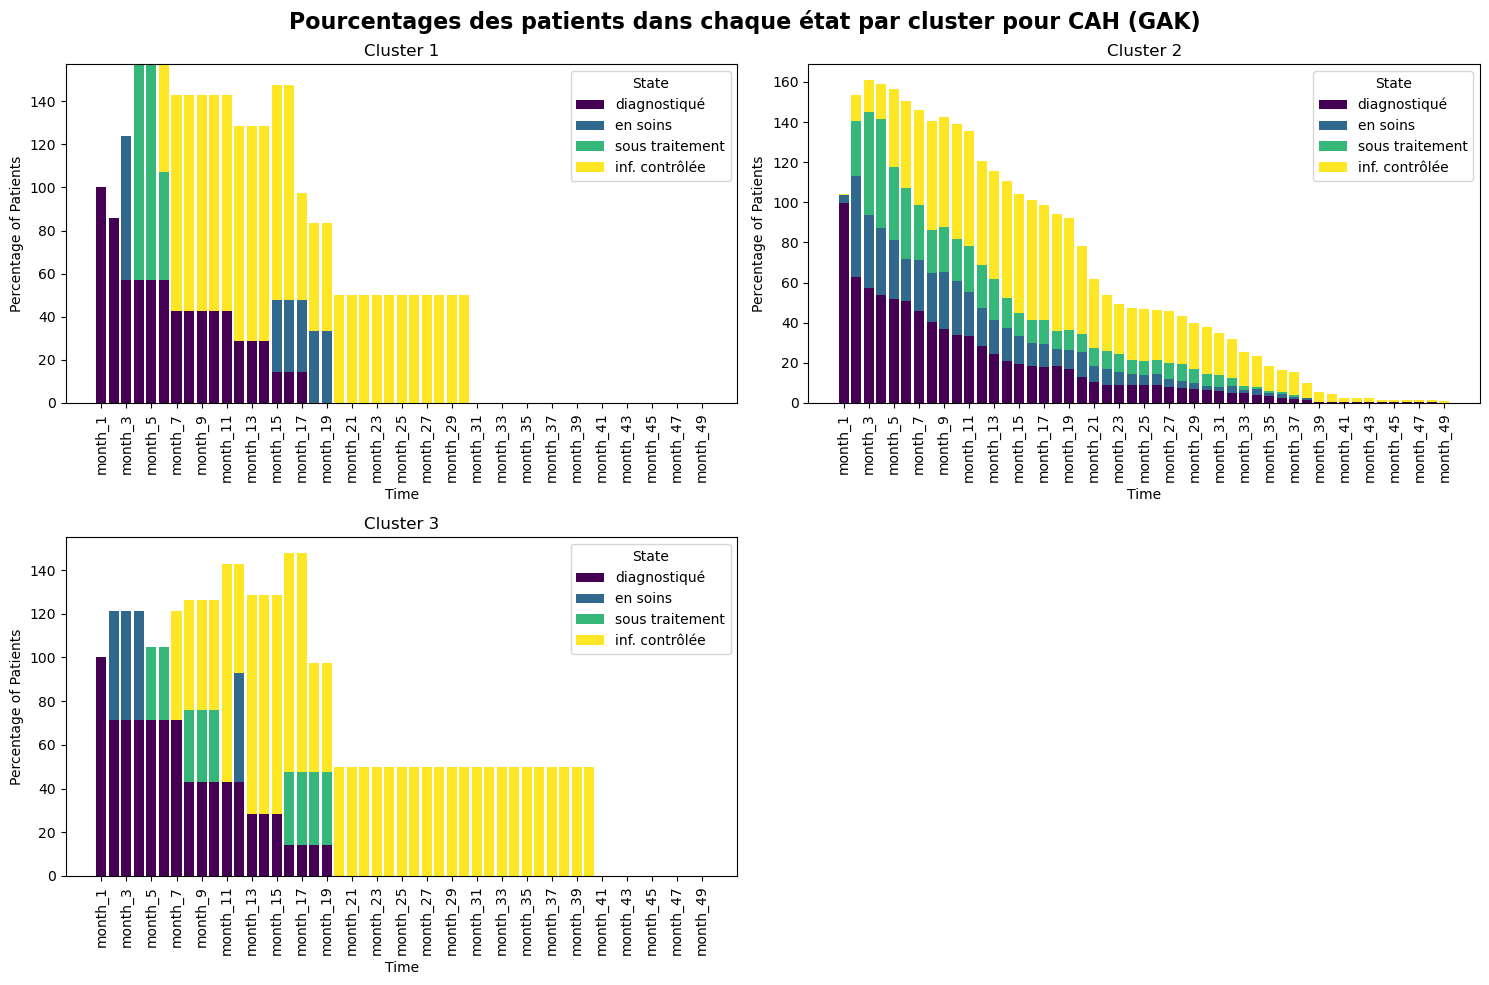

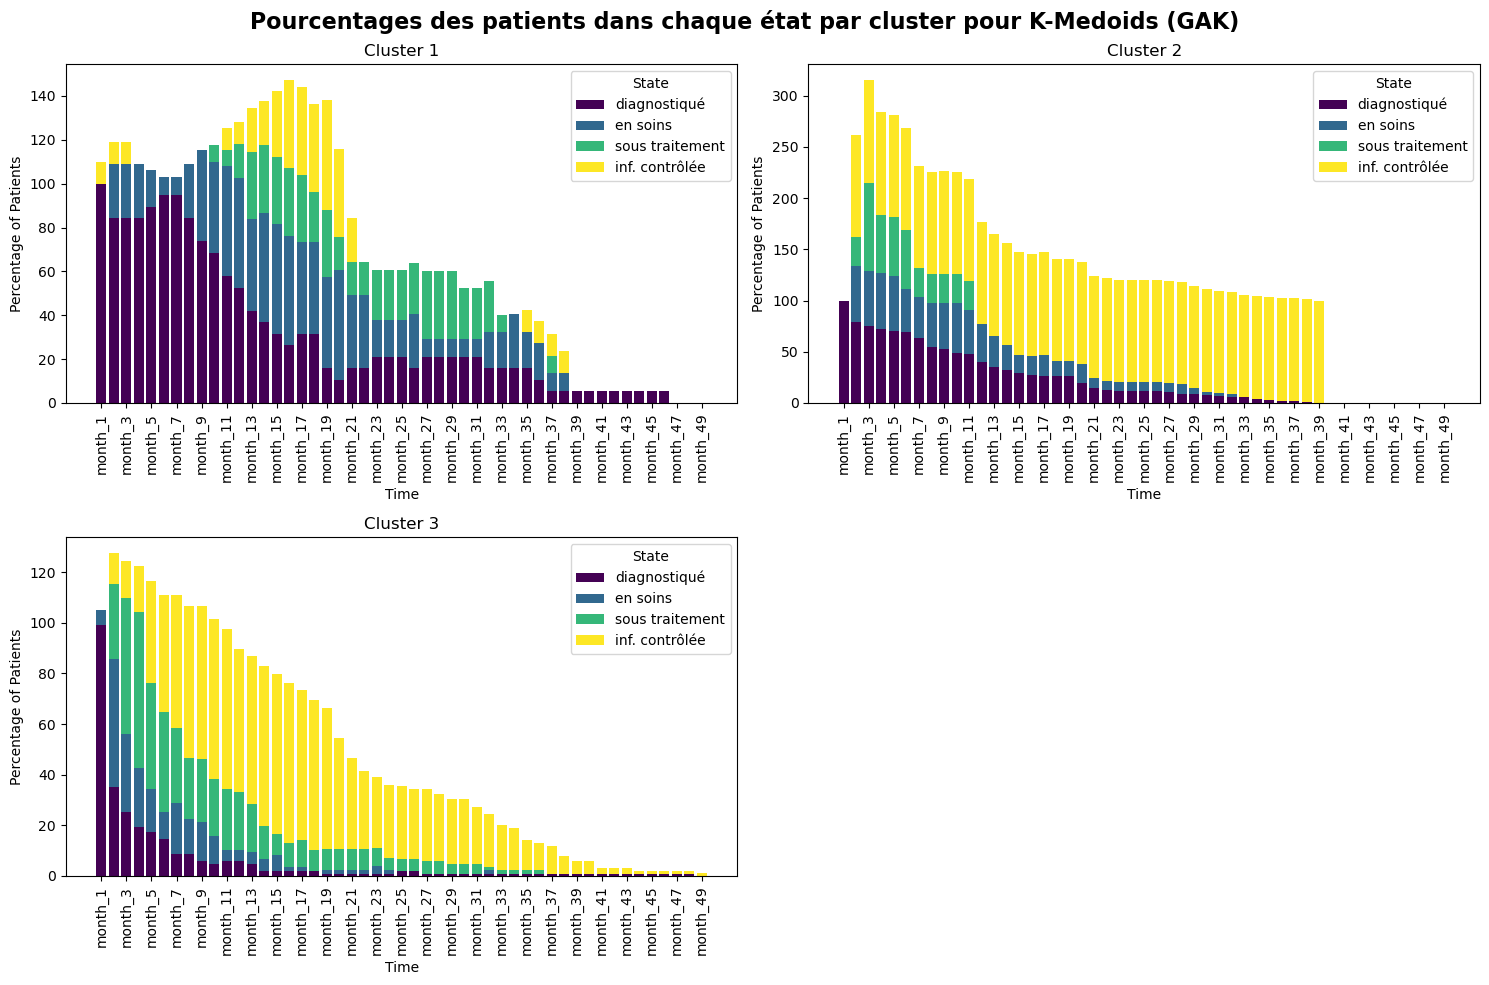

In [33]:
tca.bar_treatment_percentage(clusters=clusters_gak, title="Pourcentages des patients dans chaque état par cluster pour CAH (GAK)")
tca.bar_treatment_percentage(clusters=kmedoids_labels_gak, title="Pourcentages des patients dans chaque état par cluster pour K-Medoids (GAK)")

On remarque que pour OM, pour CAH, on avait bien un cluster avec une grande majorité de patients qui sont seulement diagnostiqués, un 2ème avec les patients qui sont encore sous traitements ou en soins à la fin de l'étude, et un dernier avec une majorité de patients qui ont l'infection contrôlée à la fin.
Et pour K-medoids, on avait la même chose mais avec les clusters 1 et 3 inversés.

Il semble donc intéréssants de se centrer sur la métrique OM pour la suite de nos interprétations. 

# 5. Ajouts

On peut maintenant faire nos analyses pour une seule distance, ici on choisit Optimal Matching (elle tourne assez rapidement au final)

## 5.1. Entropie transversale (Traminer)
L'entropie montre à quel point les patients sont dispersés ou non à un instant $t$. L'entropie mesure le désordre :
- Entropie = 0 : Tous les patients sont dans le même état (ex: tout le monde est au stade "Diagnostic").
- Entropie = 1 (maximum) : Les patients sont répartis équitablement entre tous les états possibles. C'est la diversité maximale.

Pic d'entropie au début : Signifie que les patients commencent leur parcours de manières très différentes.

Baisse de l'entropie à la fin : Signifie que le parcours de soins renvoie les patients vers un état commun (souvent la guérison ou la fin de suivi).

Un cluster avec une entropie toujours basse est un cluster "robuste" (prévisible). Un cluster avec une entropie haute est un groupe instable.

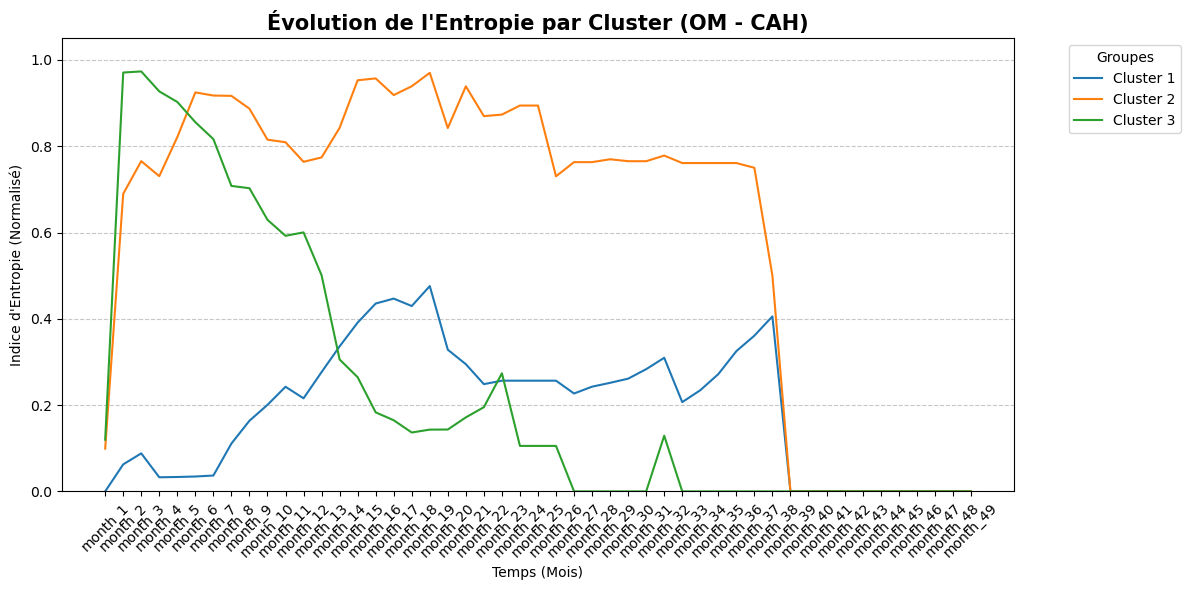

In [34]:
plot_transversal_entropy(tca, clusters=clusters_OM, title="Évolution de l'Entropie par Cluster (OM - CAH)")

Le cluster 1 a une entropie faible au début, les patients sont tous dans le même état D, puis l'entropie augmente légèrement, on a certains patients qui passent aux états de soins et de traitements.

Le cluster 3 arrive assez rapidement à une entropie nulle, tous les patients finissent par avoir le même état (infection contrôlée)

Et le cluster 2 a une entropie qui tombe à 0 car on arrive à la fin de l'étude et donc tous les patients sont à l'état nan, mais on a une entropie assez élevée tout le long, on alterne entre plusieurs états.

Cette fonction semble donc plus intéresantes pour des variables comme mvad_data, on saura que lorsque l'entropie s'approche de 0, ce n'est pas à caus d'un manque d'information mais parce que les patients finissent par avoir le même état.

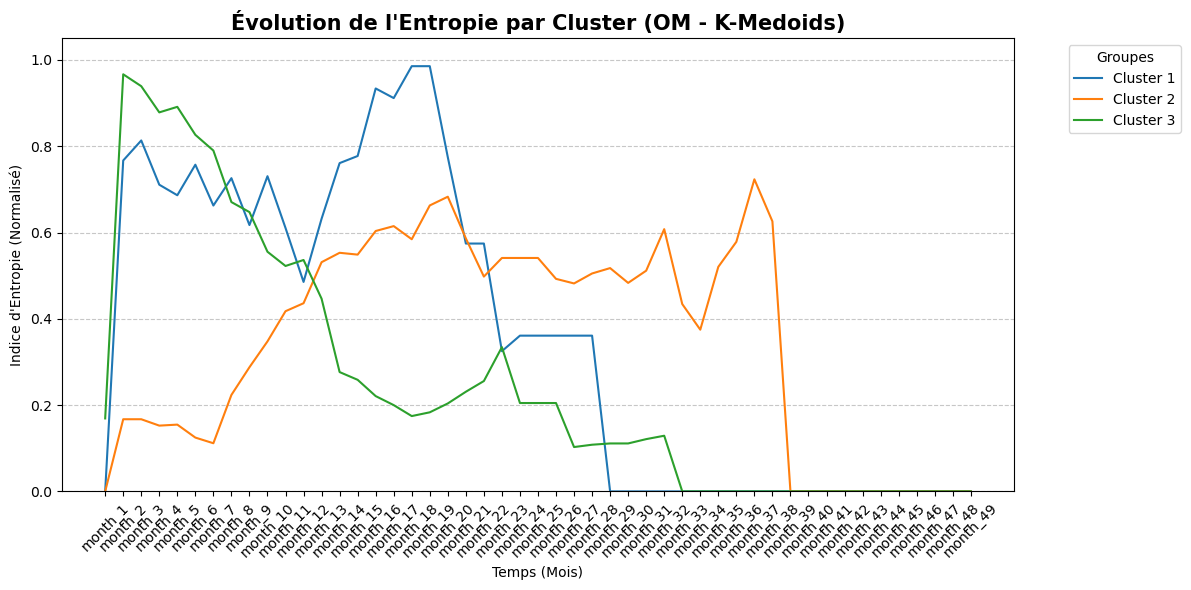

In [35]:
plot_transversal_entropy(tca, clusters=kmedoids_labels_OM, title="Évolution de l'Entropie par Cluster (OM - K-Medoids)")

Pour k-medoids, les clusters 1 et 3 ont assez rapidement une entropie nulle. Mais on remarque pour le cluster 2 l'entropie augmente au cours des mois.

## 5.2. Mean Time Plot (Traminer)

Durée Moyenne par État (Equivalent `seqmtplot`) : Ce graphique donne le temps total passé dans chaque phase du parcours de soins. Celui-ci montre combien de temps durent les états.

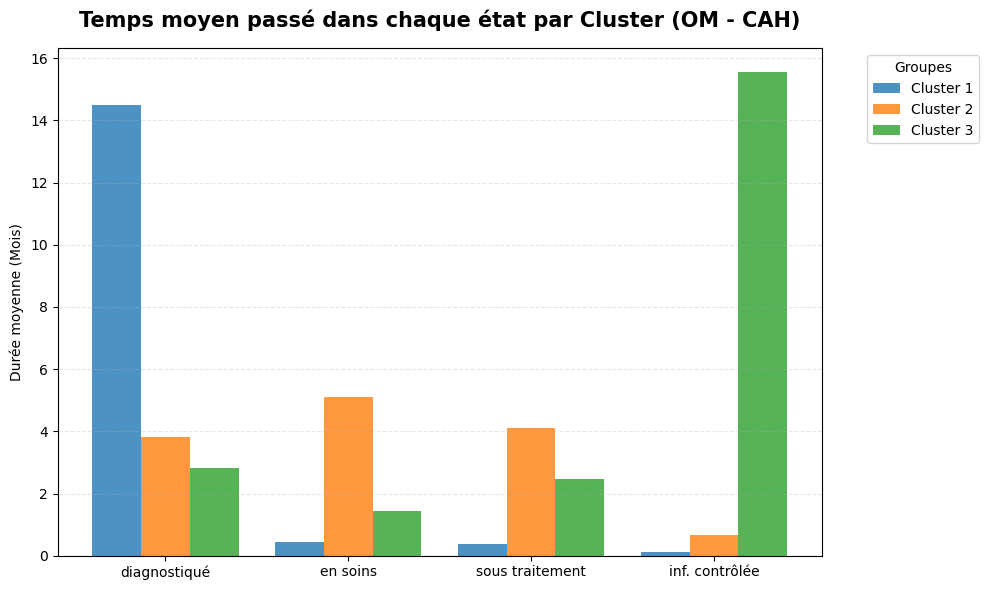

In [36]:
plot_mean_time(tca, clusters=clusters_OM, title="Temps moyen passé dans chaque état par Cluster (OM - CAH)")

On voit que le cluster 1 est majoritairement dans l'état diagnostiqué, tandis que pour le cluster 2, on passe par tous les états mais on est assez peu dans infection controlée.
Alors que le cluster 3 est majoritairement à l'état d'infection controlée.

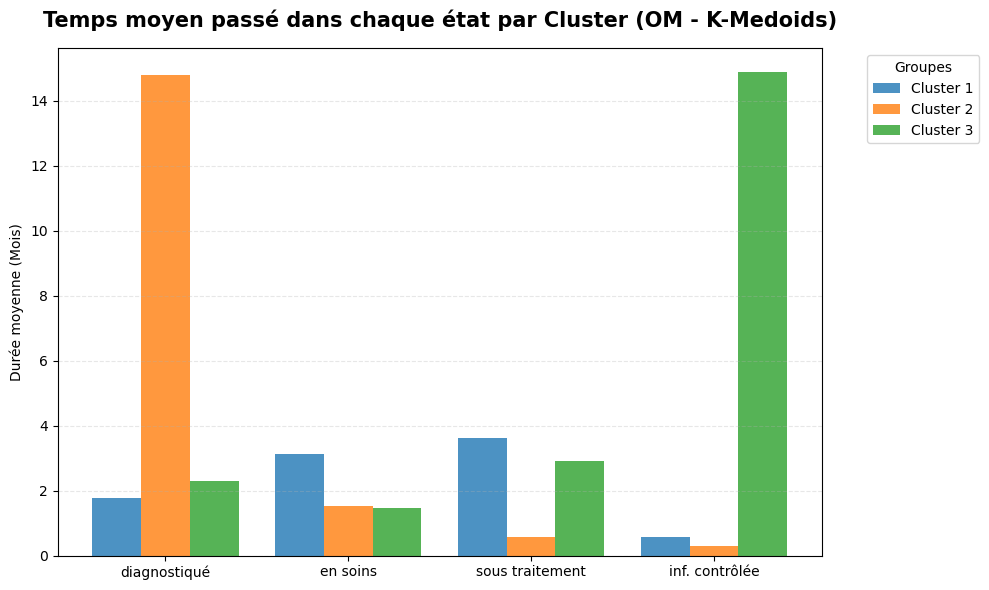

In [37]:
plot_mean_time(tca, clusters=kmedoids_labels_OM, title="Temps moyen passé dans chaque état par Cluster (OM - K-Medoids)")

Ici, on est dans le meme cas que précedemment, avec els clusters 1 et 2 inversés.

## 5.3. Trajectoires médoïdes 
On peut aussi introduire l'équivalent à la fonction `seqrep` de Traminer, elle extrait dans chaque cluster la trajectoire d'un patient qui est le "meilleur" medoid, elle calcule le pourcentage de patients dans le cluster qui ont un parcours similaire. On utilisera cette fonction `extract_rep_seq` pour comparer entre eux nos clusters avec cette fois-ci des trajectoires réelles ($\neq$ trajectoires modales), et cela permet aussi de vérifier que nos patients dans chaque clusters sont assez proches de leurs médoids.

Le choix de `coverage_threshold` dépend de la matrice de couts, si une substitution coute 1, un seul de 5 par exemple signifie qu'on considère qu'un patient est représenté par la séquence de médoide s'il y a au maximum l'équivalent de 5 mois de différence/substitution entre lui et le médoïde.

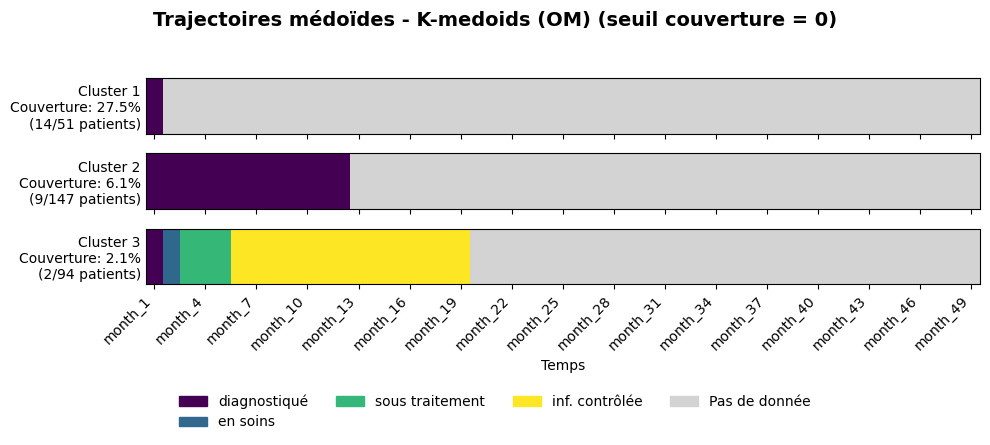

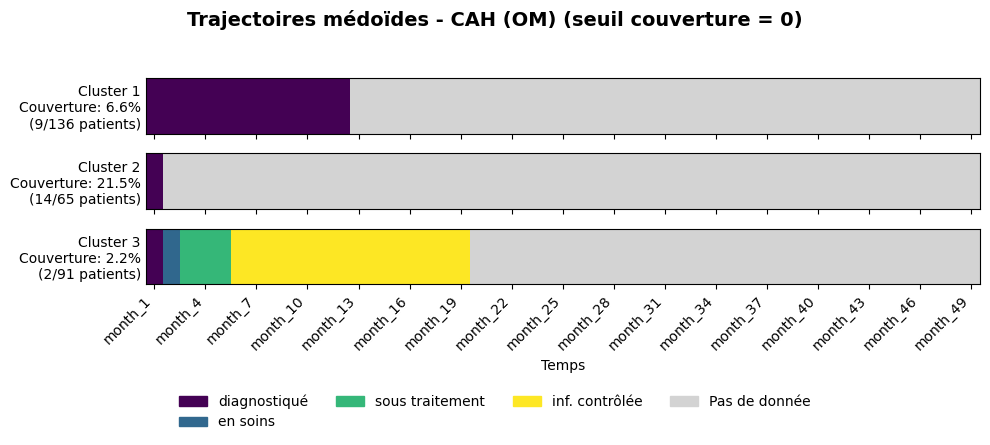

In [38]:
df_seq = tca.data.drop(columns=[tca.index_col])

seuil_couverture0 = 0

resultats_rep_kmed = extract_representative_sequences(
        df_sequences=df_seq, 
        distance_matrix=distance_matrix_OM, 
        cluster_labels=kmedoids_labels_OM, 
        coverage_threshold=seuil_couverture0
    )

resultats_rep_cah = extract_representative_sequences(
        df_sequences=df_seq, 
        distance_matrix=distance_matrix_OM, 
        cluster_labels=clusters_OM, 
        coverage_threshold=seuil_couverture0
    )

plot_representative_sequences(tca, resultats_rep_kmed, title=f"Trajectoires médoïdes - K-medoids (OM) (seuil couverture = {seuil_couverture0})")
plot_representative_sequences(tca, resultats_rep_cah, title=f"Trajectoires médoïdes - CAH (OM) (seuil couverture = {seuil_couverture0})")

Lorsqu'on a un seuil de couverture de 0, c'est à dire qu'on cherche les trajectoires du cluster qui sont identiques à celle du médoïde, relativement à la distance OM, on remarque que les cluster 1 de CAH et 2 de K-médoïdes sont assez bien représenté, mais on cherche un seuil de couverture qui n'est pas trop grand, mais qui maximise le taux de couverture pour tous les clusters.

La distance maximale est : 1.99


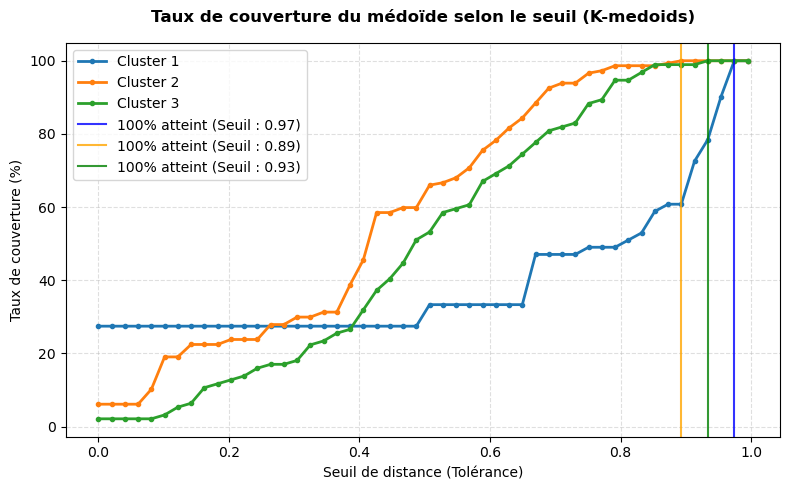

In [39]:
# Pour K-medoids (DTW) :

max_dist = np.max(distance_matrix_OM)
print(f"La distance maximale est : {max_dist:.2f}")

pourcentages_a_tester = np.linspace(0, 50, 50) # 50 points entre 0 et 50 (%)
seuils_a_tester = (pourcentages_a_tester / 100) * max_dist 
taux1 = []
taux2 = []
taux3 = []

for seuil in seuils_a_tester:
    res = extract_representative_sequences(df_seq, distance_matrix_OM, kmedoids_labels_OM, coverage_threshold=seuil)
    taux1.append(res[1]['coverage_rate'])
    taux2.append(res[2]['coverage_rate'])
    taux3.append(res[3]['coverage_rate'])

taux1_array = np.array(taux1)
taux2_array = np.array(taux2)
taux3_array = np.array(taux3)

indices1_100 = np.where(taux1_array >= 99.9)[0]
indices2_100 = np.where(taux2_array >= 99.9)[0]
indices3_100 = np.where(taux3_array >= 99.9)[0]

seuil1_100 = None
if len(indices1_100) > 0:
    premier_index_100 = indices1_100[0]
    seuil1_100 = seuils_a_tester[premier_index_100]

seuil2_100 = None
if len(indices2_100) > 0:
    premier_index_100 = indices2_100[0]
    seuil2_100 = seuils_a_tester[premier_index_100]

seuil3_100 = None
if len(indices3_100) > 0:
    premier_index_100 = indices3_100[0]
    seuil3_100 = seuils_a_tester[premier_index_100]

plt.figure(figsize=(8, 5))
plt.plot(seuils_a_tester, taux1_array, marker='.', linestyle='-', color='tab:blue', linewidth=2, label='Cluster 1')
plt.plot(seuils_a_tester, taux2_array, marker='.', linestyle='-', color='tab:orange', linewidth=2, label='Cluster 2')
plt.plot(seuils_a_tester, taux3_array, marker='.', linestyle='-', color='tab:green', linewidth=2, label='Cluster 3')

if seuil1_100 is not None:
    plt.axvline(x=seuil1_100, color='blue', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil1_100:.2f})')


if seuil2_100 is not None:
    plt.axvline(x=seuil2_100, color='orange', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil2_100:.2f})')

if seuil3_100 is not None:
    plt.axvline(x=seuil3_100, color='green', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil3_100:.2f})')

plt.title("Taux de couverture du médoïde selon le seuil (K-medoids)", fontweight='bold', pad=15)
plt.xlabel("Seuil de distance (Tolérance)")
plt.ylabel("Taux de couverture (%)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

La courbe du cluster 1 stagne autour d'un seuil à 60% avant d'augmenter grandement à partir d'un seuil de 90%. (On commencait déjà avec un taux de couverture égal à 20%, ce qui explique pourquoi il était assez bon, même avec un seuil nul).
Ce cluster contient des trajectoires assez différentes du médoïde.

Un seuil de couverture de 70% semble intéressant :
* Pour le cluster 1, un peu moins de 50% du cluster est couvert, c'est à dire qu'on a 50% des trajectoires du cluster sont identiques à celle du médoïde à 70%, relativement à la distance OM, c'est moins bien couvert que les autres clusters, mais ce clusters possèdent plusieurs trajectoires assez différentes les unes des autres.
* Pour le cluster 2, environ 95% du cluster est couvert, c'est à dire qu'on a 95% des trajectoires du cluster sont identiques à celle du médoïde à 70%, relativement à la distance OM.
* Pour le cluster 3, plus de 80% du cluster est couvert, c'est à dire qu'on a 80% des trajectoires du cluster sont identiques à celle du médoïde à 70%, relativement à la distance OM.

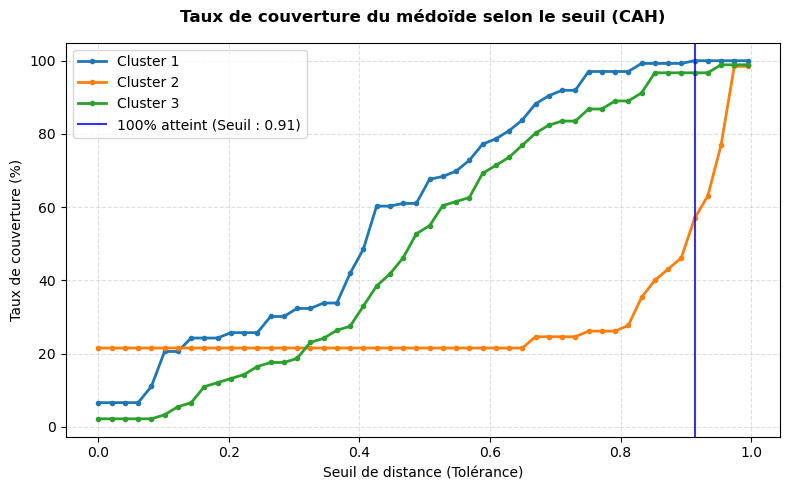

In [40]:
# Pour CAH (DTW) :
pourcentages_a_tester = np.linspace(0, 50, 50) # 50 points entre 0 et 50 (%)
seuils_a_tester = (pourcentages_a_tester / 100) * max_dist 
taux1 = []
taux2 = []
taux3 = []

for seuil in seuils_a_tester:
    res = extract_representative_sequences(df_seq, distance_matrix_OM, clusters_OM, coverage_threshold=seuil)
    taux1.append(res[1]['coverage_rate'])
    taux2.append(res[2]['coverage_rate'])
    taux3.append(res[3]['coverage_rate'])

taux1_array = np.array(taux1)
taux2_array = np.array(taux2)
taux3_array = np.array(taux3)

indices1_100 = np.where(taux1_array >= 99.9)[0]
indices2_100 = np.where(taux2_array >= 99.9)[0]
indices3_100 = np.where(taux3_array >= 99.9)[0]

seuil1_100 = None
if len(indices1_100) > 0:
    premier_index_100 = indices1_100[0]
    seuil1_100 = seuils_a_tester[premier_index_100]

seuil2_100 = None
if len(indices2_100) > 0:
    premier_index_100 = indices2_100[0]
    seuil2_100 = seuils_a_tester[premier_index_100]

seuil3_100 = None
if len(indices3_100) > 0:
    premier_index_100 = indices3_100[0]
    seuil3_100 = seuils_a_tester[premier_index_100]

plt.figure(figsize=(8, 5))
plt.plot(seuils_a_tester, taux1_array, marker='.', linestyle='-', color='tab:blue', linewidth=2, label='Cluster 1')
plt.plot(seuils_a_tester, taux2_array, marker='.', linestyle='-', color='tab:orange', linewidth=2, label='Cluster 2')
plt.plot(seuils_a_tester, taux3_array, marker='.', linestyle='-', color='tab:green', linewidth=2, label='Cluster 3')

if seuil1_100 is not None:
    plt.axvline(x=seuil1_100, color='blue', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil1_100:.2f})')

if seuil2_100 is not None:
    plt.axvline(x=seuil2_100, color='orange', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil2_100:.2f})')

if seuil3_100 is not None:
    plt.axvline(x=seuil3_100, color='green', linestyle='-', alpha=0.8, 
                label=f'100% atteint (Seuil : {seuil3_100:.2f})')

plt.title("Taux de couverture du médoïde selon le seuil (CAH)", fontweight='bold', pad=15)
plt.xlabel("Seuil de distance (Tolérance)")
plt.ylabel("Taux de couverture (%)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

Pour le cluster 2, on stagne autour de 20% jusqu'à ce qu'on atteigne un seuil de couverture de 0.80, le taux de couverture commence à augmenter.
Cela montre que ce cluster n'a pas un médoïde très représentatif, on a vu que pour cette trajectoire, on avait assez rapidement plus de données, et les trajectoires de ce cluster sont assez différentes les unes des autres.
Il semble intéressant ici de choisir un seuil de couverture autour de 80%.

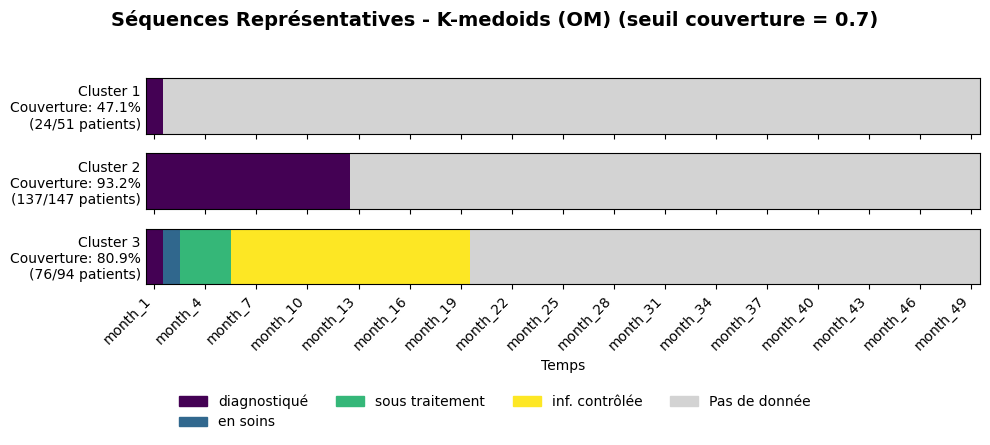

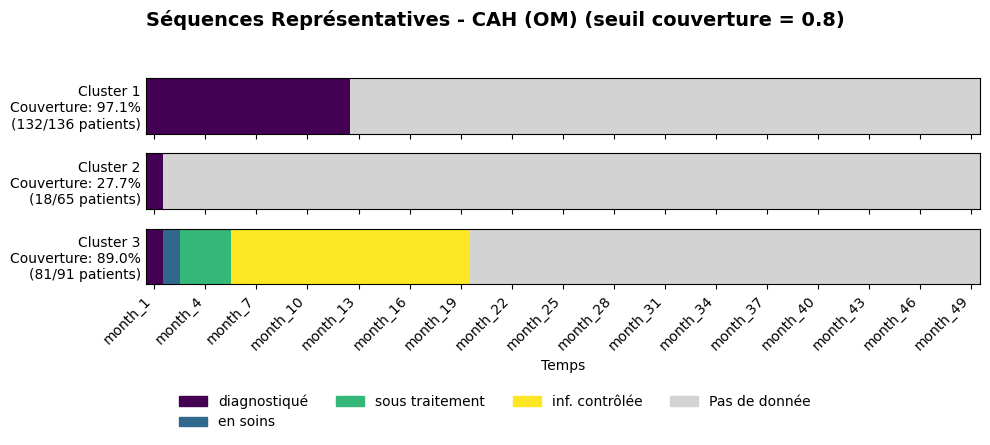

In [41]:
seuil_kmed = 0.7
seuil_cah = 0.8

resultats_rep_kmed = extract_representative_sequences(
        df_sequences=df_seq, 
        distance_matrix=distance_matrix_OM, 
        cluster_labels=kmedoids_labels_OM, 
        coverage_threshold=seuil_kmed
    )

resultats_rep_cah = extract_representative_sequences(
        df_sequences=df_seq, 
        distance_matrix=distance_matrix_OM, 
        cluster_labels=clusters_OM, 
        coverage_threshold=seuil_cah
    )

plot_representative_sequences(tca, resultats_rep_kmed, title=f"Séquences Représentatives - K-medoids (OM) (seuil couverture = {seuil_kmed})")
plot_representative_sequences(tca, resultats_rep_cah, title=f"Séquences Représentatives - CAH (OM) (seuil couverture = {seuil_cah})")

Avec ces seuils la, une grande majorité des patients sont représentés par les médoïdes de leur cluster.

## 5.3 V2 Trajectoires médoïdes juste pour K-médoïds

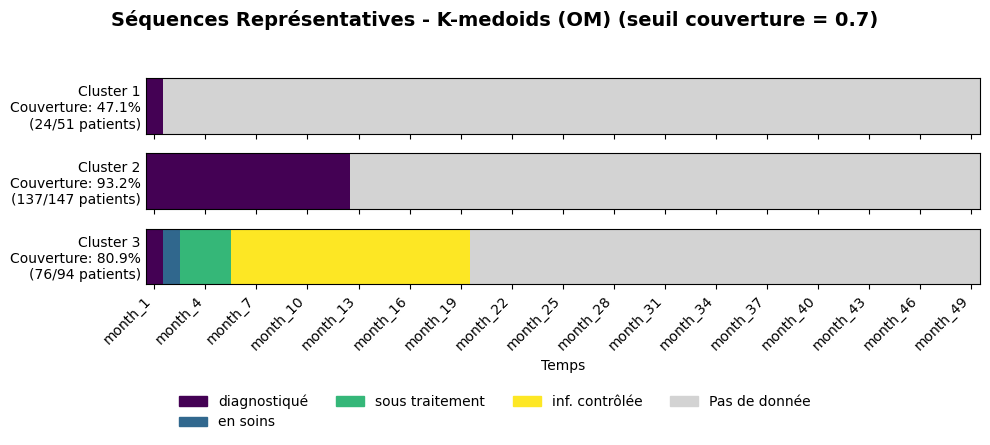

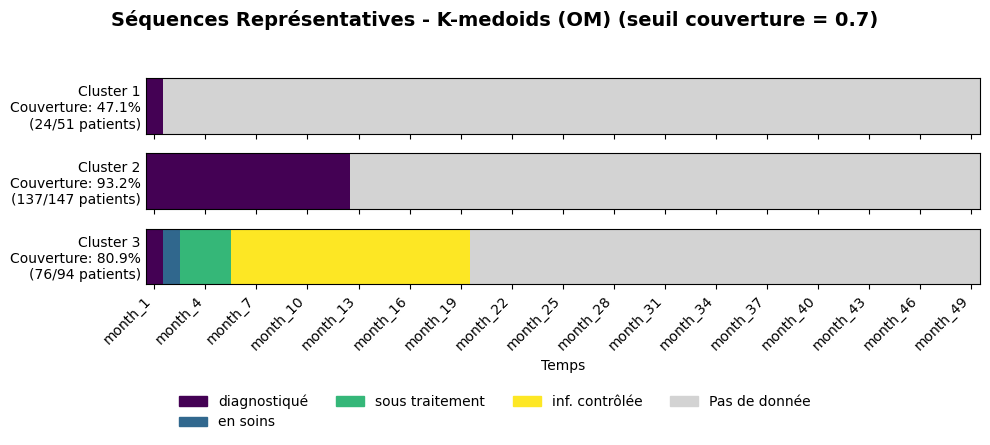

In [42]:
res = extract_coverage_kmedoids(
    df_sequences=df_seq, 
    distance_matrix=distance_matrix_OM, 
    cluster_labels=kmedoids_labels_OM, 
    medoids_indices=medoid_indices_OM,
    coverage_threshold=seuil_kmed
)

plot_representative_sequences(tca, res, title=f"Séquences Représentatives - K-medoids (OM) (seuil couverture = {seuil_kmed})")
plot_representative_sequences(tca, resultats_rep_kmed, title=f"Séquences Représentatives - K-medoids (OM) (seuil couverture = {seuil_kmed})")


Pour k-medoid, pas besoin de recalculer les médoïdes, on les a déjà et cela donne les mêmes résultats pour les 2 fonctions.

## 5.4. SeqTree

Cette méthode croise le profil des patients (age, sexe,...) avec leurs séquences temporelles. Il prend en entrée les covariables et cherche quelle variable sépare le mieux les patients en groupes avec des parcours de soins similaires.

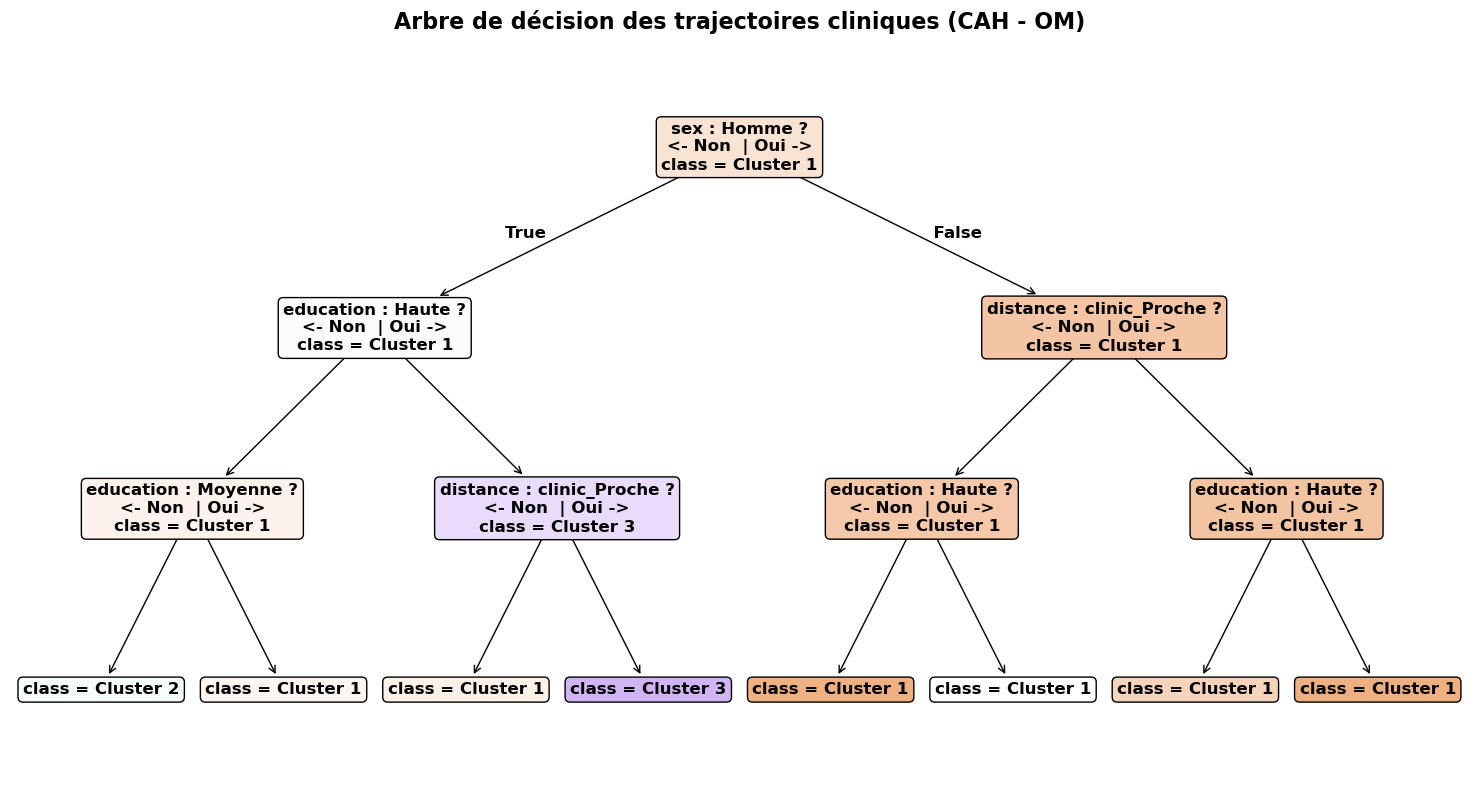

In [43]:
arbre_cah = plot_trajectory_decision_tree(
    df_clinical=col_stats, 
    cluster_labels=clusters_OM,
    max_depth=3,  # On limite à 3 étages
    variables_label=label_var,
    titre="Arbre de décision des trajectoires cliniques (CAH - OM)"
)

Plus le cluster à la fin est foncé, plus ce profil a de chances d'être dans ce cluster.

* CAH :
    * Les femmes proches de la clinique avec une education haute ont plus de chances d'être dans le cluster 3.
    * Les femmes avec une éducation basse ont plus de chances d'être dans le cluster 2.
    * Les hommes qui sont éloignés de la clinique et qui ont une basse ou moyenne éducation ont plus de chances d'être dans le cluster 1.

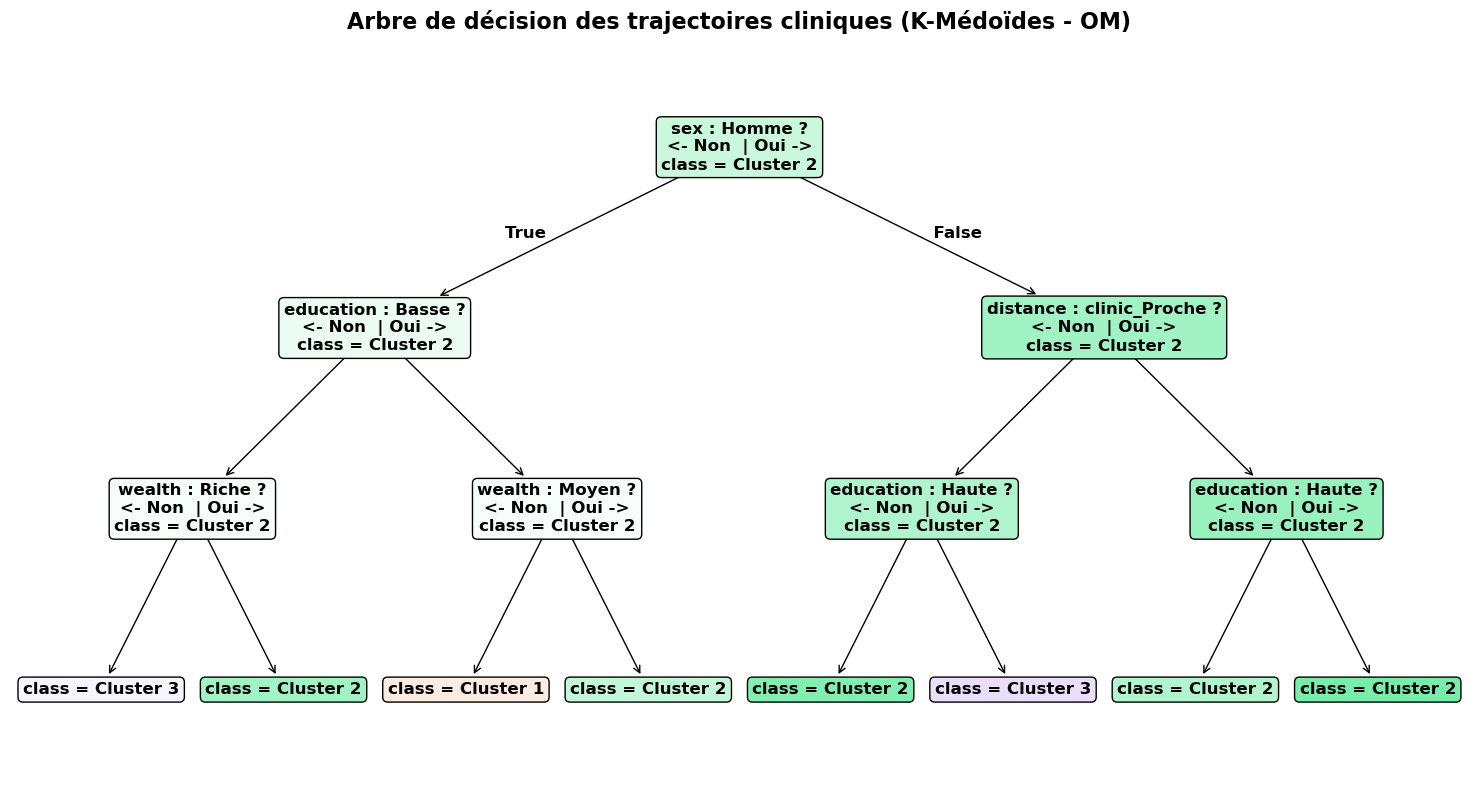

In [44]:
arbre_kmed = plot_trajectory_decision_tree(
    df_clinical=col_stats, 
    cluster_labels=kmedoids_labels_OM,
    max_depth=3,
    variables_label=label_var,
    titre="Arbre de décision des trajectoires cliniques (K-Médoïdes - OM)"
)

* K-Medoids :
    * Les hommes avec une basse ou moyenne éducation ont plus de chances d'être dans le cluster 3.
    * Les femmes avec une éducation basse et pauvres/riches ont plus de chances d'être dans le cluster 1.
    * Les hommes avec une haute éducation et qui sont loins de la cliniques ont plus de chances d'être dans le cluster 2.

## 5.5. Analyse du temps jusqu'à l'infection controlée (S)
On peut visualiser la rapidité à laquelle les patients de chaque cluster atteignent l'état S. A chaque mois, quel pourcentage de patients de chaque cluster a atteint l'état S.

Pour ce faire, on utilise a librairie `lifelines`.

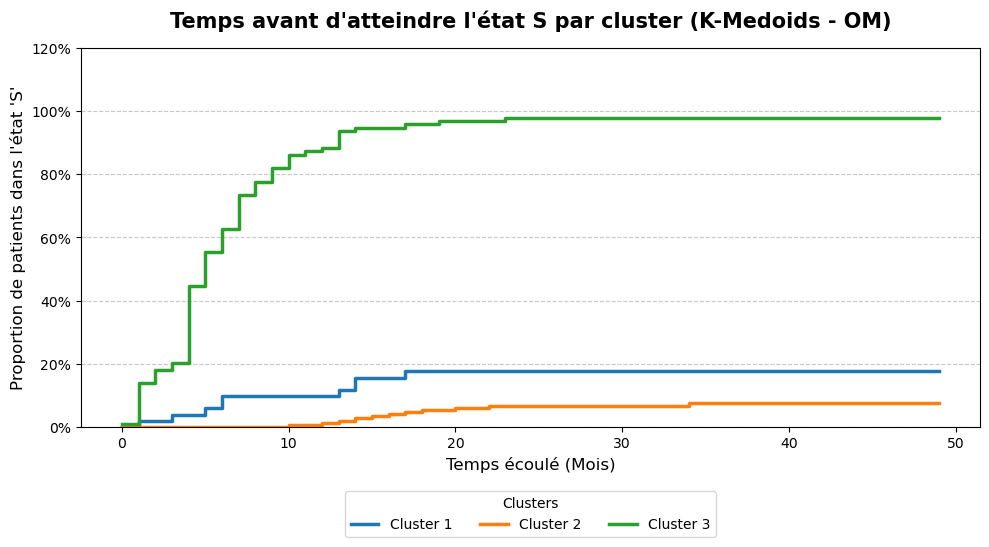

In [45]:
df_seq = tca.data.drop(columns=[tca.index_col])

plot_time_to_event(
    df_sequences=df_seq, 
    cluster_labels=kmedoids_labels_OM, 
    target_state='S',
    titre=f"Temps avant d'atteindre l'état S par cluster (K-Medoids - OM)"
)

* K-medoids :
    * La majorité des patients du cluster 3 n'atteignent jamais l'état d'infection contrôlée, ils sont toujours à l'état de diagnostic.
    * Moins de 20% des patients du cluster 1 sont à l'état S, cela stagne à partir de 17 mois environ.
    * On arrive très rapidement proches des 100% de patients à l'état d'infection contrôlée pour le cluster 2.


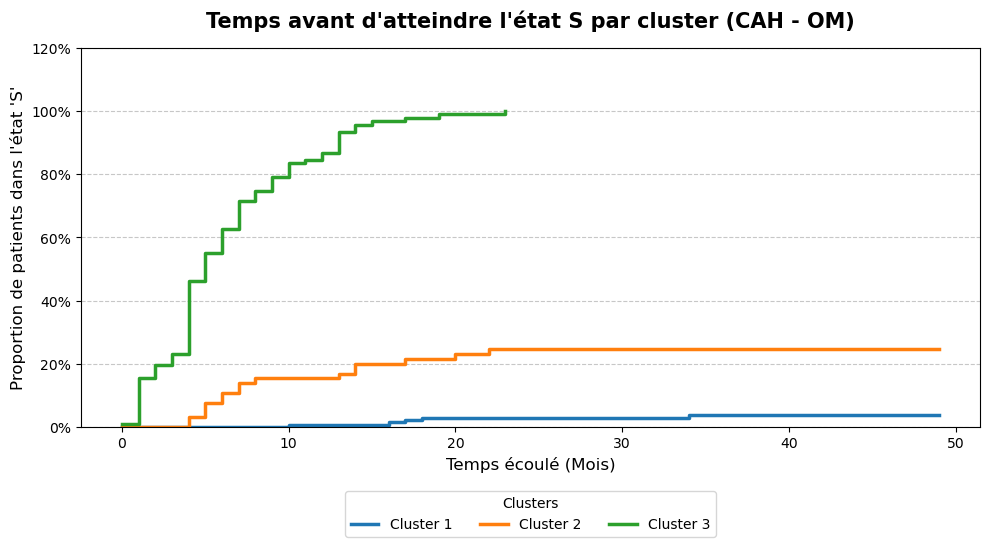

In [46]:
plot_time_to_event(
    df_sequences=df_seq, 
    cluster_labels=clusters_OM, 
    target_state='S',
    titre=f"Temps avant d'atteindre l'état S par cluster (CAH - OM)"
)

* CAH :
    * La majorité des patients du cluster 1 n'atteignent jamais l'état d'infection contrôlée.
    * Un peu plus de 20% des patiets du cluster 2 finissent à l'état d'infection contrôlée, mais cela stagne au bout de 22 mois environ ici.
    * On arrive plus rapidement à presque 100% de patients à l'état d'infection contrôlée pour le cluster 3.

## 5.6. Projection des variables sur les clusters

Cette fonction permet de visualiser pour chaque variable la répartition des patients dans chaque cluster.

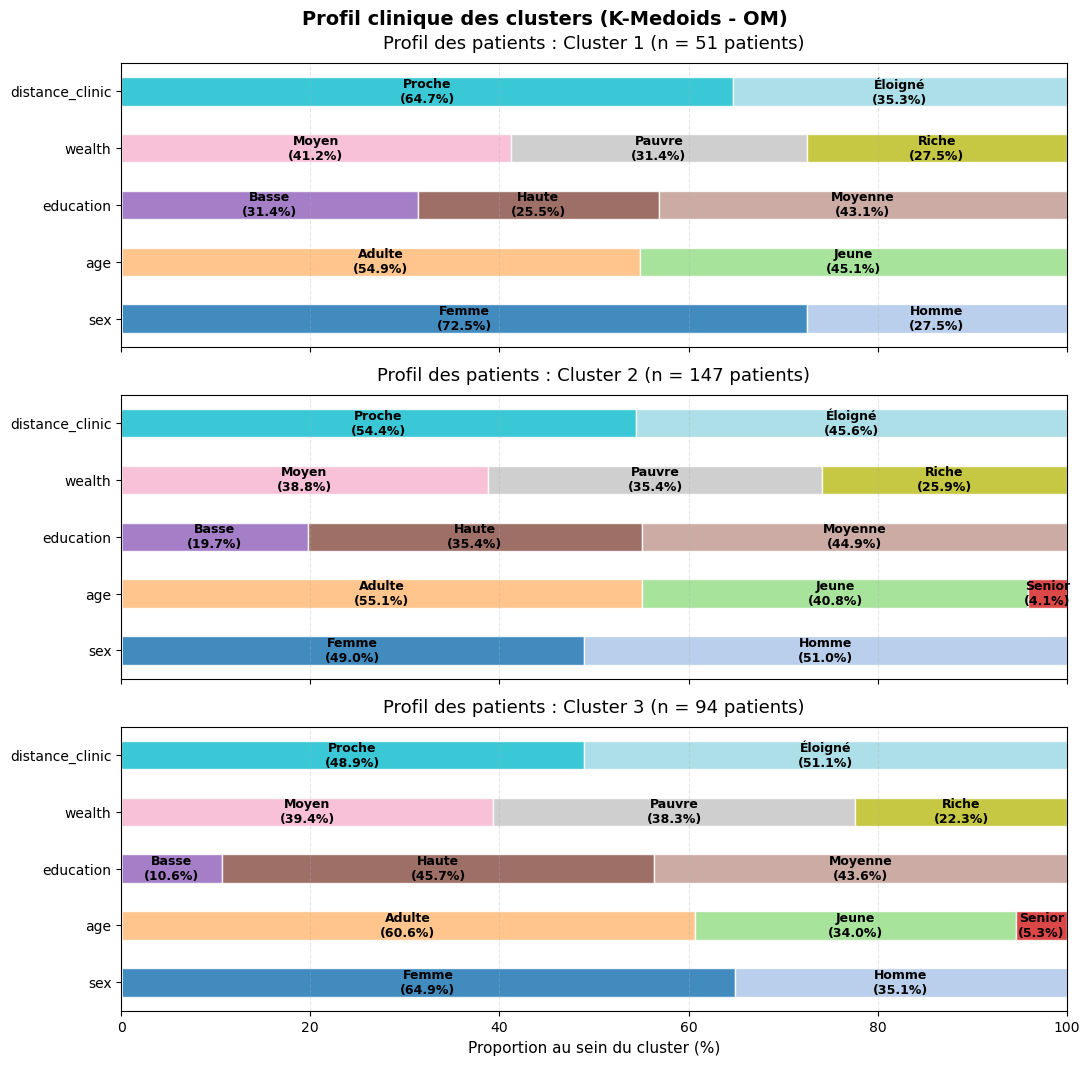

In [47]:
plot_cluster_profiles(
    df_clinical=col_stats, 
    cluster_labels=kmedoids_labels_OM, variables_label=label_var, titre="Profil clinique des clusters (K-Medoids - OM)"
)

* K-medoid :
    * Majorité de femmes dans les clusters 1 et 3 / petite majorité d'hommes dans le cluster 3.
    * Peu de seniors dans les tous les clusters / majorité d'adultes dans tous les clusters / Pas de seniors dans le cluster 1.
    * Niveau d'étude moyen très présentdans les 3 clusters / peu de niveau d'études bas pour le cluster 3 / peu de hautes études pour le cluster 1.
    * A peu près la même répartition de richesse pour les 3 clusters.
    * Majorité de patients proches dans le cluster 1.

Profil des clusters selon CAH (OM) :


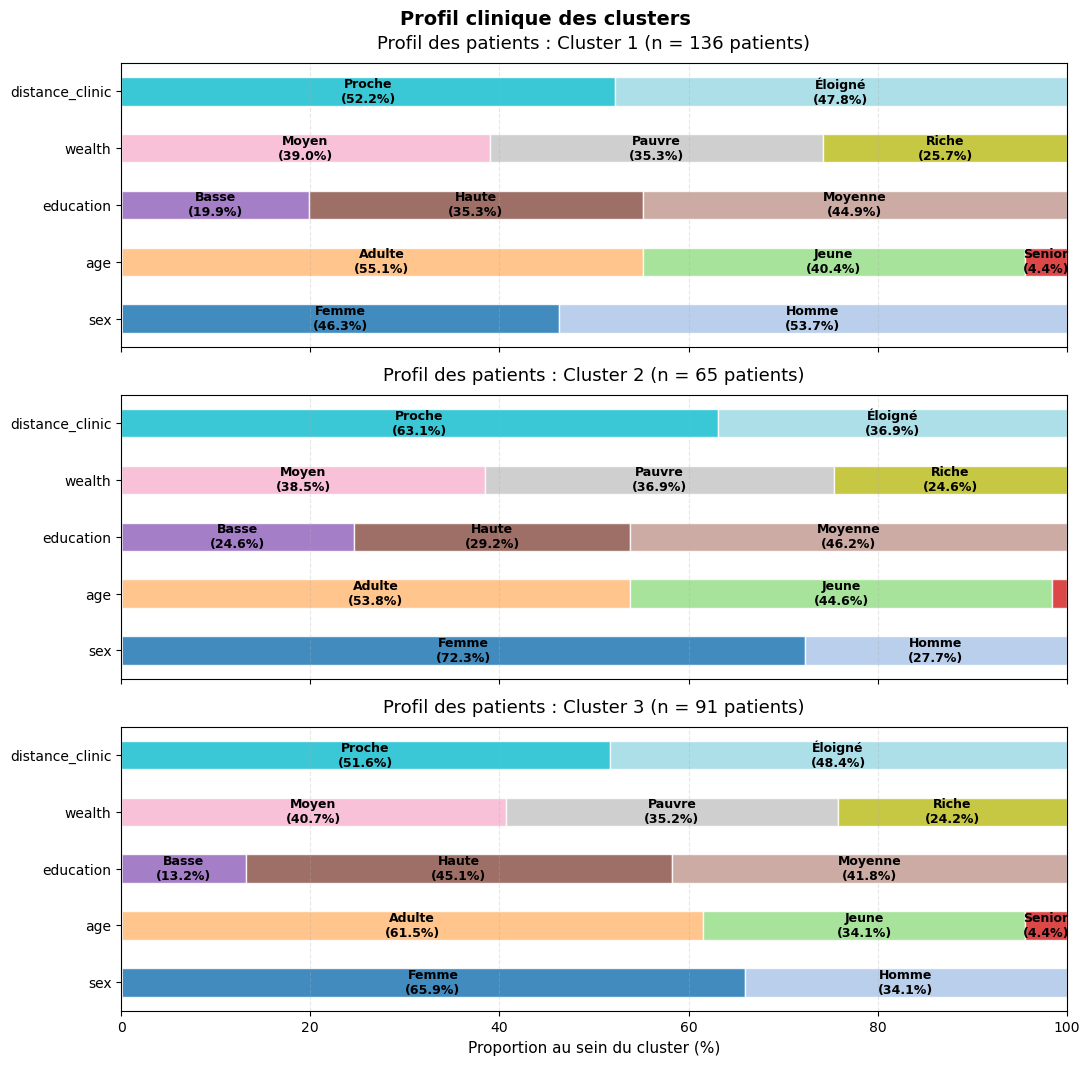

In [48]:
print("Profil des clusters selon CAH (OM) :")
plot_cluster_profiles(
    df_clinical=col_stats, 
    cluster_labels=clusters_OM, variables_label=label_var
)

* CAH :
    * Plus de femmes dans les clusters 2 et 3 / plus d'hommes dans le cluster 1
    * Seniors minimes dans le cluster 2
    * Haut et moyen niveaux d'éducation en majorité dans le cluster 3
    * Cluster 2 plus proche

Il serait intéressant de voir les différences avec la population totale.

## 5.7. Analyse des Transitions les plus fréquentes
 Cette analyse identifie les passages d'un état à un autre qui séparent le plus les clusters. Cela permet de caractériser les clusters par les changements d'états que les patients ont le plus fréquemmebt.

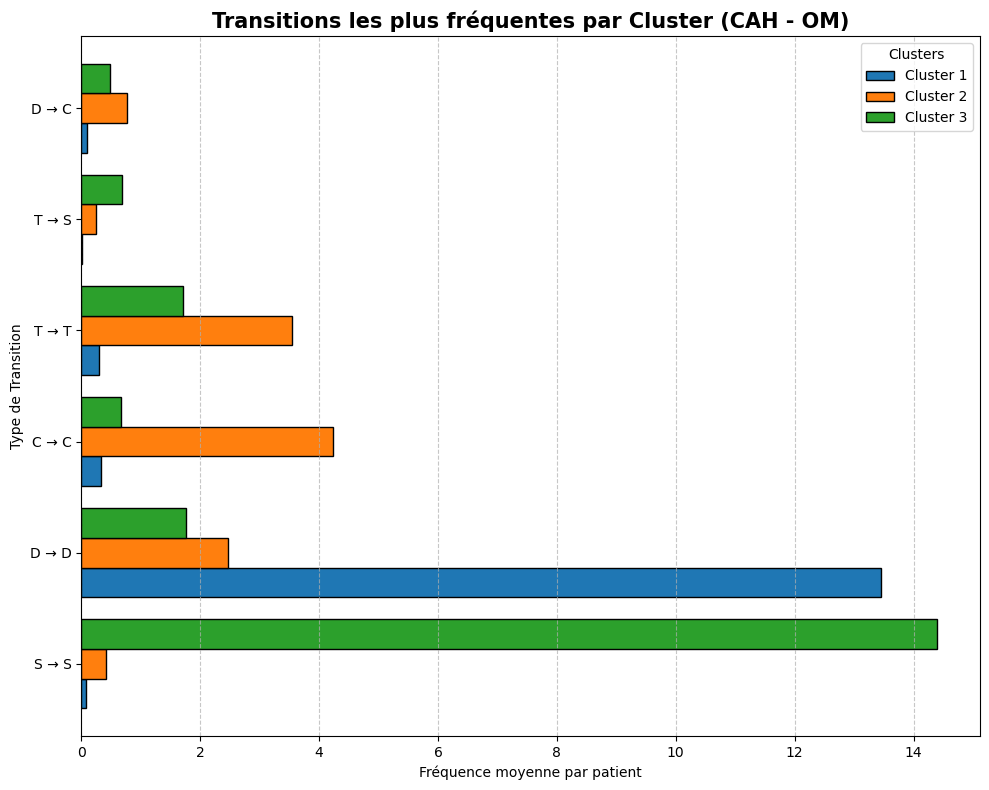

In [49]:
plot_frequent_transitions(tca, clusters_OM, n_top=6, titre="Transitions les plus fréquentes par Cluster (CAH - OM)")

* Pour le cluster 1, on a une transition précise, on reste à l'état D.
* Pour le cluster 2, on n'a pas vraiment de transition qui apparaît le plus, on traverse un peu tous les états, mais on est majoritairement dans les états T et C
* Pour le cluster 3, on a en majorité la transition S->S

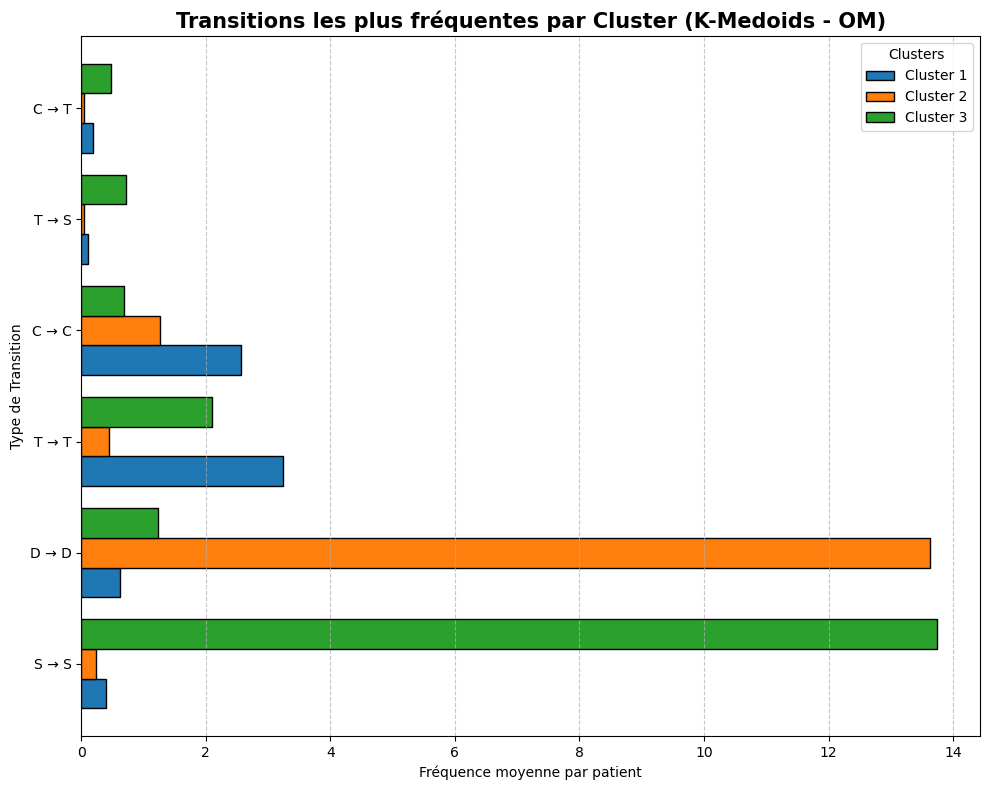

In [50]:
plot_frequent_transitions(tca, kmedoids_labels_OM, n_top=6, titre="Transitions les plus fréquentes par Cluster (K-Medoids - OM)")

On a à peu près les mêmes transitions ici, avec les clusters 1 et 2 inversés.

## 5.8. Trajectoires les plus éloignées


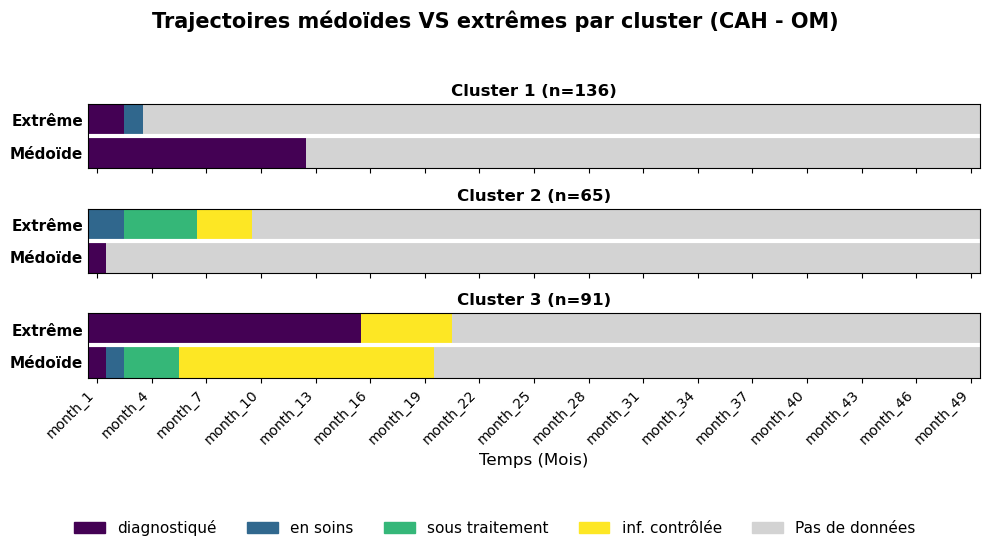

In [51]:
plot_extreme_trajectories(tca, clusters=clusters_OM, 
                              distance_matrix=distance_matrix_OM,
                              title="Trajectoires médoïdes VS extrêmes par cluster (CAH - OM)")

* Cluster 1 : La trajectoire la plus extrême se superpose avec la trajectoire du médoïde au début, elle passe ensuite en soins mais on n'a plus de données, le médoïde représente donc assez bien même les trajectoires les plus atypiques du cluster.
* Cluster 2 : La trajectoire la plus différente du médoïde est celle d'un patient qui est rapidement passé à l'état d'infection contrôlée avant de ne plus avoir de données. Le médoïde du cluster n'avait rapidement plus de données, donc c'est cette trajectoire qui est la "plus proche" de toutes les trajectoires car elle a le moins de données, donc pour passer de cette trajectoire à une autre il faut seulement "remplir" les NaN**********.
* Cluster 3 : Ici la trajectoire la plus éloignée est celle d'un patient qui était à l'état de diagnostic au départ, de passer rapidement à l'état d'infection contrôlée, toutefois il reste assez proche de la trajectoire médoïde, en effet le médoïde passe rapidement lui aussi à l'état d'infection contrölée.

Dans ce cas, les clusters sont assez bien représentés par leurs médoïdes, même les trajectoires les plus éloignées s'en rapprochent.
Mais le medoide du cluster 1 est presque le meme que celui du cluster 2.

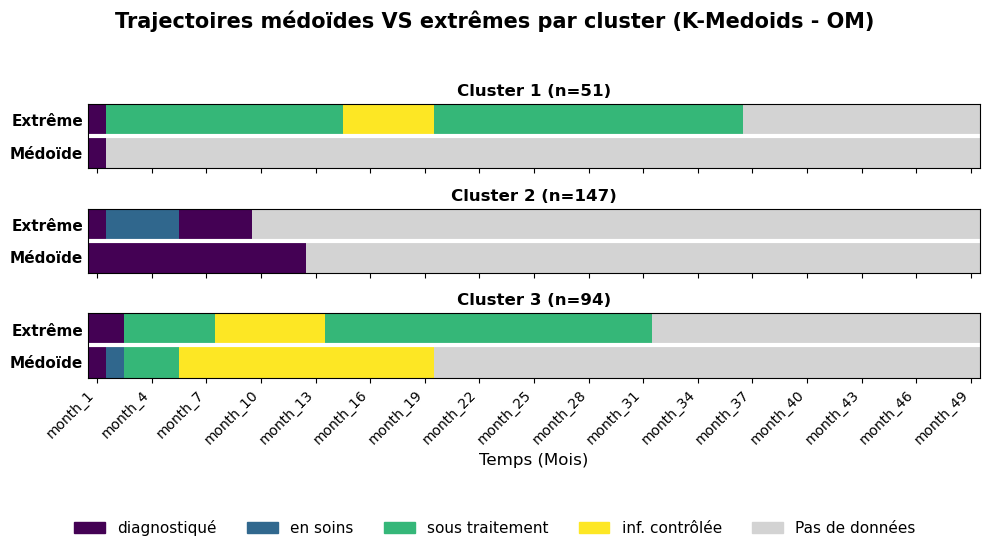

In [52]:
plot_extreme_trajectories(tca, clusters=kmedoids_labels_OM, 
                              distance_matrix=distance_matrix_OM,
                              title="Trajectoires médoïdes VS extrêmes par cluster (K-Medoids - OM)")

* Cluster 1 : Ici, on voit que dans le cluster où on a une majorité de patients en soins et en traitements,ce patient a alterné entre S et T, mais il ne suit pas le médoïde qui avait peu de données
* Cluster 2 : la trajectoire la plus éloignée est celle d'un patient qui était en diagnostic au départ, avant de passer à l'état de soins, et de revenir à diagnostic puis de ne plus avoir de données, toutefois il reste assez proche de la trajectoire médoïde, en effet le médoïde reste à l'état de diagnostic.
* Cluster 3 : Dans ce cluster, le médoïde passe par plusieurs états, mais est en majorité à l'état d'infection controlée, le patient le plus éloignée a passé lui aussi quelques mois à l'état d'infection contrôlée.

Les médoïdes représentent assez bien les patients dans leurs clusters, sauf le cluster 2 qui a un médoïde avec assez peu de données.
Ici, aussi le médoide du cluster 2 ressemble à celui du cluster 3.

## 5.9. Résumé des clusters

In [53]:
print("CAH (OM) :")
rep1 = summarize_clusters(tca=tca, clusters=clusters_OM)

CAH (OM) :
RESUME  DES CLUSTERS

CLUSTER 1 : 'D-DOMINANT'
   • Taille       : 136 patients (46.6% des patients)
   • État Fréquent     : 'D' (durée moyenne : 14.5 mois)
   • Transitions fréquentes   : D → D, C → C

CLUSTER 2 : 'C-DOMINANT'
   • Taille       : 65 patients (22.3% des patients)
   • État Fréquent     : 'C' (durée moyenne : 5.1 mois)
   • Transitions fréquentes   : C → C, T → T

CLUSTER 3 : 'S-DOMINANT'
   • Taille       : 91 patients (31.2% des patients)
   • État Fréquent     : 'S' (durée moyenne : 15.5 mois)
   • Transitions fréquentes   : S → S, D → D



In [54]:
print("K-medoids (OM) :")
rep2 = summarize_clusters(tca=tca, clusters=kmedoids_labels_OM)

K-medoids (OM) :
RESUME  DES CLUSTERS

CLUSTER 1 : 'T-DOMINANT'
   • Taille       : 51 patients (17.5% des patients)
   • État Fréquent     : 'T' (durée moyenne : 3.6 mois)
   • Transitions fréquentes   : T → T, C → C

CLUSTER 2 : 'D-DOMINANT'
   • Taille       : 147 patients (50.3% des patients)
   • État Fréquent     : 'D' (durée moyenne : 14.8 mois)
   • Transitions fréquentes   : D → D, C → C

CLUSTER 3 : 'S-DOMINANT'
   • Taille       : 94 patients (32.2% des patients)
   • État Fréquent     : 'S' (durée moyenne : 14.9 mois)
   • Transitions fréquentes   : S → S, T → T



## 5.10. Représentation des patients dans les clusters

La fonction suivante génère une Heatmap des écarts. Elle permet de visualiser la « signature » de chaque cluster en mettant en évidence quelles caractéristiques y sont sur-représentées ou sous-représentées par rapport à la population globale.

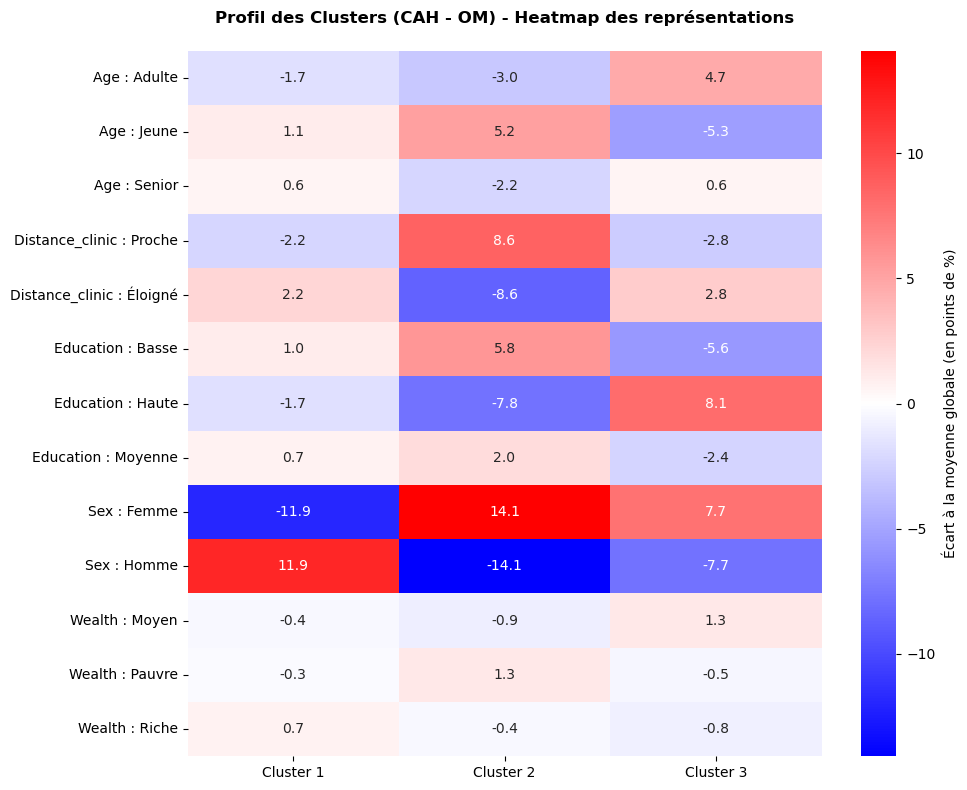

In [55]:
profil_clusters_heatmap(col_stats, clusters_OM, label_var, titre="Profil des Clusters (CAH - OM) - Heatmap des représentations")

Ex : Il y a en moyenne 11,9% de plus d'hommes dans le cluster 1 par rapport à la population globale.
Il y a en moyenne 11,9% de moins de femmes dans le cluster 1 par rapport à la population globale.

Tester d'autres couleurs

* Cluster 1 : 
    * Les hommes, les patients éloignés de la clinique sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les adultes, les patients avec un haut degré d'éducation sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Le cluster avec une majorité de patients à l'état de diagnostic durant l'enquête contient plutôt des profils d'hommes assez jeunes qui vivent éloignés de l'hopital.


* Cluster 2 :
    * Les femmes, les patients proches de la clinique, ceux avec un bas degré d'éducation et les jeunes sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les adultes et seniors, les patients avec un haut degré d'éducation sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Les patients qui passent par plusieurs traitements et soins ont plutot un profil de femmes jeunes, avec un bas degré d'éducation (peut-être dû à leur jeunesse) et vivant proches de la clinique (peut-être résidant à l'hopital pour leurs soins).

* Cluster 3 :
    * Les femmes, les patients éloignés de la clinique, les adultes, et ceux avec un haut degré d'éducation sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les jeunes, les patients avec des bas et moyens degrés d'éducation sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Les patients qui arrivent rapidement à l'état d'infection contrôlée, sont plutôt des femmes adultes avec un haut degré d'éducation, mais vivant loin de la clinique.

La variable 'Wealth' donnent des écarts compris entre -1 et +1 point pour l'ensemble des clusters. Cela montre que la répartition des niveaux de richesse au sein de chaque trajectoire est assez identique à celle de la population globale.

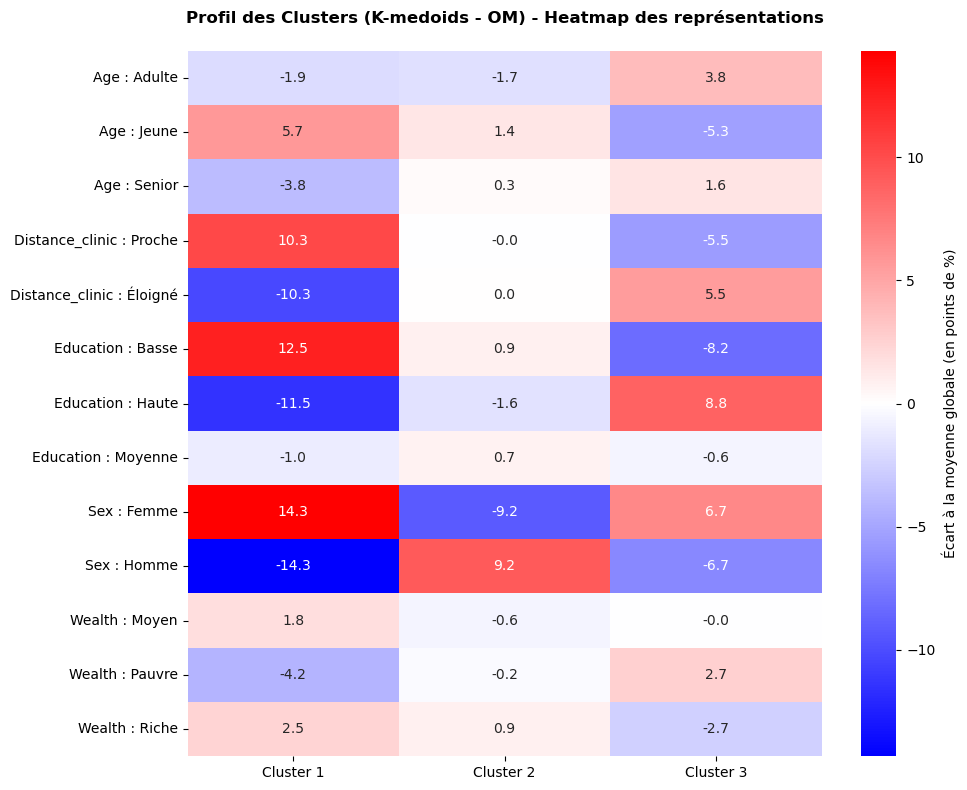

In [56]:
profil_clusters_heatmap(col_stats, kmedoids_labels_OM, label_var, titre="Profil des Clusters (K-medoids - OM) - Heatmap des représentations")

* Cluster 1 :
    * Les femmes, les patients proches de la clinique, les jeunes, et ceux avec un bas degré d'éducation sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les adultes et seniors, les patients avec des hauts d'éducation, et qui ont un faible salaire sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Les patients qui passent par plusieurs états de soins et traitement, sont plutôt des femmes jeunes avec un bas degré d'éducation, et vivant proches de la clinique.

* Cluster 2 : 
    * Les hommes, les jeunes sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les adultes, les patients avec un haut degré d'éducation sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Le cluster avec une majorité de patients à l'état de diagnostic durant l'enquête contient plutôt des profils d'hommes assez jeunes avec un bas ou moyen degré d'éducation.

* Cluster 3 :
    * Les femmes, les adultes, les patients éloignés de la clinique, ceux avec un haut degré d'éducation et qui sont plus pauvres sont sur-représentées dans ce cluster par rapport à la moyenne globale.
    * Les jeunes, les patients avec un bas degré d'éducation et un salaire élevé sont sous-représentées dans ce cluster par rapport à la moyenne globale.
    * Les patients qui arrivent rapidement à l'état d'infection contrôlée ont plutot un profil de femmes adultes, avec un haut degré d'éducation mais un salaire faible et vivant loins de la clinique.

On remarque des similarités entre les clusters des 2 méthodes :

* Le groupe "Diagnostic" est dominé par de jeunes hommes (Cluster 1 CAH / Cluster 2 K-médoïdes).
* Le groupe "Soins et Traitements" est dominé par de jeunes femmes, peu éduquées et vivant à proximité (Cluster 2 CAH / Cluster 1 K-médoïdes).
* Le groupe "Infection Contrôlée" est dominé par des femmes adultes, plus éduquées et vivant loin (Cluster 3 CAH / Cluster 3 K-médoïdes).